<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana C. Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago A. Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>Edição:</b> 2/2021 | <b>Editora:</b> LTC</div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2021 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>


 <hr style="height:5px"> 

    
<h2>Aprendizado de Máquina em Bioinformática</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/4012668928932051">Pedro Reis Pires</a>

 <hr style="height:2px"> 

## Introdução

Microarranjo de DNA, ou *microarray*, é uma técnica que busca representar genes de interesse em uma amostra, através de uma coleção ordenada de fragmentos gênicos [1]. 

Muito se desenvolveu desde a *Southern Blot*, primeira técnica de _array_ biológico para análise de sequências específicas dentro de uma única amostra de DNA [6]. Atualmente, *microarrays* conseguem armazenar milhões de fragmentos do DNA, possibilitando análises bastante completas [5].

Um dos objetivos da análise de _microarray_ é identificar genes associados com uma condição fisiológica. A proposta de usá-los para o diagnóstico de câncer foi inicialmente sugerida por Khan *et al.* [4], estudando uma amostra de rabdomiosarcoma alveolar, e reforçada pelo estudo de Golub *et al.* [3], que distinguiram a leucemia mielóide aguda da leucemia linfocítica aguda pelo perfil de expressão gênica, através de algoritmos de classificação e agrupamento.

Identificar o tipo de leucemia de um paciente através de técnicas automáticas é algo extremamente interessante, visto que essa não é um tarefa fácil. Sendo normalmente realizada por um médico, não existem muitos dados claros que permitam essa distinção de forma simples, sendo muitas vezes realizadas apenas pela experiência e opinião do médico para o caso em questão [3].

Neste *notebook*, será realizado um experimento sobre uma base real da área de bioinformática. Nele, serão tratados dois problemas distintos, com objetivos semelhantes: classificação e agrupamento de amostras de microarranjo de DNA de pacientes leucêmicos. A motivação e dados utilizados são provenientes do artigo *Molecular Classification of Cancer: Class Discovery and Class Prediction by Gene Expression Monitoring*, de Golub *et al.* [3]. 

É esperado que, através deste *notebook*, o leitor possa verificar diversas das técnicas apresentadas no livro e exploradas em outros *notebooks* que acompanham este material, sendo aplicadas na prática, através de um problema e dados reais. O objetivo final do experimento é reforçar conceitos já apresentados, e preparar o leitor para aplicar aprendizado de máquina em problemas futuros, da etapa de análise inicial dos dados até a avaliação dos algoritmos executados.

Este _notebook_ se refere, de forma geral, às Seções **I (Preparação de Dados)**, **II (Modelos Preditivos)** e **III (Modelos Descritivos)**, e ao Capítulo **18 (Decomposição de Problemas Multiclasse)**

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/3.1.1/index.html) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`scipy`](https://www.scipy.org) (versão 1.2.1 ou superior): conjunto de funções úteis para Ciência de Dados
* [`scikit-learn`](https://scikit-learn.org/stable/)  (versão 0.22.2 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial

Também serão utilizadas as bibliotecas [`ast`](https://docs.python.org/3/library/ast.html), para trabalhar com a sintaxe de Python diretamente no código, [`os`](https://docs.python.org/3/library/os.html), para realizar tarefas específicas ao Sistema Operacional, e [`re`](https://docs.python.org/3/library/re.html), para trabalhar com expressões regulares. Por fazerem parte da [Biblioteca Padrão de Python](https://docs.python.org/pt-br/3/library/), instalação destas bibliotecas não é necessária.

In [1]:
# -*- coding: utf-8 -*-

# Bibliotecas gerais
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import scipy
%matplotlib inline

# Algoritmos de classificação
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

# Protocolo experimental da classificação
from ast import literal_eval
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import ParameterGrid, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Algoritmos de agrupamento
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering

# Protocolo experimental do agrupamento
from sklearn.metrics.cluster import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import euclidean_distances

---
## Função auxiliar

Iremos implementar uma função, `colorize`, para ser utilizada repetidamente dentro do *notebook*. A função recebe um vetor de rótulos (`data`) em formato de `list` ou `numpy.ndarray` e retorna um vetor de códigos HTML para cores como um `numpy.ndarray`, para ser usado nos gráficos. **Obs**.: embora bibliotecas de gráficos, como a `matplotlib`, disponibilizem maneiras de colorir seus gráficos, suas paletas de cores não são adequadas para daltonismo. A função contorna este problema.

In [2]:
def colorize(data):
    color_palette = ['#D62728', '#078F8F', '#DF6B00', '#B16FFD', '#8F4A00', '#48018D', '#FDFD6F', 
                     '#074752', '#FCB5DA', '#22FF25', '#036CD7', '#6BB6FE', '#000000', '#FE6FB5']
    labels = np.unique(data)
    if len(labels) > len(color_palette):
        np.random.seed(1)
        color_palette += ["#%06x" % c for c in np.random.randint(0, 0xFFFFFF, len(labels)-len(color_palette))]
    color_array = np.empty(data.shape, dtype=object)
    for label, color in zip(labels, color_palette):
        color_array[np.where(data==label)] = color
    return color_array

---
## O experimento

Nesse *notebook*, iremos conduzir um experimento semelhante ao realizado no artigo **Molecular Classification of Cancer: Class Discovery and Class Prediction by Gene Expression Monitoring**, de Golub *et al.* [3]. Nele, os autores montaram uma base de dados de microarranjos de DNA contendo a expressão gênica de pacientes leucêmicos. Em seguida, aplicaram técnicas de classificação e agrupamento sobre os dados. A primeira abordagem buscou prever o tipo de leucemia do paciente através de sua expressão gênica; a segunda, verificou se é possível agrupar os tipos e subtipos de leucemia através de aprendizado não supervisionado, dando força assim à hipótese de que é possível descobrir novos tipos de leucemia através de técnica de aprendizado de máquina.

É importante ressaltar que o objetivo deste _notebook_ não é reproduzir fielmente o experimento do artigo. Nele, foram aplicados métodos diferentes dos já vistos nos demais _notebooks_ deste livro, fugindo assim do escopo desejado. O que será realizado é um passo-a-passo experimental completo, com os recursos e algoritmos implementados em _notebooks_ passados, com objetivos semelhantes aos do artigo.

Inicialmente, vamos aprender sobre o conjunto de dados que possuímos, através de uma **análise exploratória** sobre as amostras de expressão gênica. Em seguida, passaremos os dados por uma etapa de **pré-processamento**. Com os dados no formato desejado, será trabalhado o problema da **classificação** de tipos de leucemia, com a aplicação de diferentes algoritmos e medidas avaliativas. Por fim, executaremos algoritmos de **agrupamento** para realizar uma análise não supervisionada sobre os dados.

### Objetivos finais

O experimento possui então dois objetivos principais:
* O uso de técnicas de **classificação** automática, para predição dos tipos e subtipos de leucemia das amostras;
* A geração de partições através de técnicas de **agrupamento** para verificar se é possível descobrir os tipos e subtipos de leucemia sem fornecer esta informação para os algoritmos.

---
---
# Análise Exploratória

O objetivo da análise exploratória é explorar os dados que se encontram disponíveis para o experimento, com o objetivo de melhor entendê-los.


### Arquivos disponibilizados

Todos os arquivos utilizados ou relacionados ao trabalho de Golub _et al._ [3] encontram-se [disponibilizados publicamente](http://portals.broadinstitute.org/cgi-bin/cancer/publications/pub_paper.cgi?mode=view&paper_id=43).

O primeiro passo da análise exploratória é entender os arquivos que possuímos. São 16 arquivos no total, sendo eles:
* **Golub_et_al_1999.pdf**: artigo original;
* **Files_description.txt**: arquivo de texto explicando sobre os demais arquivos;
* **protocol.html**: código HTML explicando a forma em que as amostras foram coletadas e geradas;
* **table_ALL_AML_rfactors.txt**: fatores de redimensionamento utilizados nas amostras;
* **table_ALL_AML_samples.{rtf, txt}**: informações e metadados sobre cada uma das amostras (em dois formatos diferentes de arquivo);
* **data_set_ALL_AML_train.{tsv, txt}**: base de dados de treinamento (em dois formatos diferentes de arquivo);
* **data_set_ALL_AML_independent.{tsv, txt}**: base de dados de teste (em dois formatos diferentes de arquivo);
* **table_ALL_AML_predic.{rtf, txt}**: predições realizadas pelos autores e reportadas no artigo (em dois formatos diferentes de arquivo);
* **Figures_original_plus_suppl.ppt**: figuras utilizadas no artigo e outras complementares;
* **ALL_vs_AML_train_set_38_sorted.{cls, res}**: o tipo de leucemia de cada amostra da base de treinamento (em dois formatos diferentes de arquivo);
* **Leuk_ALL_AML.test.{cls, res}**: o tipo de leucemia de cada amostra da base de teste (em dois formatos diferentes de arquivo);

De todos os arquivos disponibilizados, os únicos que serão utilizados ao longo deste _notebook_ são o arquivo de metadados (**table_ALL_AML_samples.txt**), e os de treino e teste (**data_set_ALL_AML_train.tsv** e **data_set_ALL_AML_independent.tsv**). A escolha das extensões se deu pela facilidade de leitura através de código.

Inicialmente, como boa prática de código, iremos definir constantes para serem utilizadas ao longo da implementação. São elas: o diretório dos arquivos, os nomes dos arquivos e um valor padrão para preencher espaços nulos nas tabelas que serão lidas/geradas.

**Importante:** é necessário **fazer o _download_ dos arquivos que serão utilizados, disponibilizados [aqui](http://portals.broadinstitute.org/cgi-bin/cancer/publications/pub_paper.cgi?mode=view&paper_id=43)**,  e **salvá-los no mesmo diretório deste *notebook***. Os arquivos devem ficar dentro de um sub-diretório, cujo nome deve ser armazenado na variável `DATA_DIR` abaixo. Por padrão, chamaremos esse diretório de `data`.

In [3]:
# Diretório dos arquivos
DATA_DIR = 'data'

# Nomes dos arquivos
METADATA_FILE = 'table_ALL_AML_samples.txt'
TRAIN_FILE = 'data_set_ALL_AML_train.tsv'
TEST_FILE = 'data_set_ALL_AML_independent.tsv'

# Valores constantes
NOT_INFORMED_VALUES = 'NI'

---
### Metadados das amostras

O arquivo **table_ALL_AML_samples.txt** possui uma tabela com diversos metadados sobre as amostras do conjunto de dados.

Temos **72** amostras no total: **38** pertencentes à base de treino e **34** à base de teste. Cada uma delas corresponde a uma amostra de Leucemia, e possuem as seguintes informações:
* **Samples**: indicador único para cada amostra
* **ALL/AML**: o tipo de Leucemia da amostra, que pode ser:
    * **_ALL_**: *Acute Lymphoblastic Leukemia*, ou Leucemia Linfocítica Aguda;
    * **_AML_**: *Acute Myeloid Leukemia*, ou Leucemia Mielóide Aguda.
* **BM/PB**: tipo de tecido do qual a amostra foi extraída, podendo ser:
    * **_BM_**: *Bone marrow*, ou medula óssea;
    * **_PB_**: *Peripheral blood*, ou sangue periférico.
* **T/B-cell**: Apenas para amostras ALL, correspondendo ao tipo (T ou B) dos linfócitos
* **FAB**: Apenas para amostras AML, [classificação francesa-americana-britânica do câncer](https://www.cancer.org/cancer/acute-myeloid-leukemia/detection-diagnosis-staging/how-classified.html), que, nas amostras, pode ser:
    * **_M1_**: Leucemia Mieloblástica Aguda com Maturação Mínima;
    * **_M2_**: Leucemia Mieloblástica Aguda com Maturação;
    * **_M4_**: Leucemia Mielomonocítica Aguda;
    * **_M5_**: Leucemia Monocítica Aguda.
* **Date**: A data de extração, representada em formato _mês/dia/ano_
* **Gender**: Gênero do paciente, representado por um único caractere (M ou F)
* **Blasts**: Número referente à características do tratamento
* **Treatment Response**: Resposta do paciente para os tratamentos, podendo ser sucesso (*Success*) ou  falha (*Failure*)
* **PS**: *Prediction Strenght*, ou força da predição, que corresponde a quanto, em porcentagem, o algoritmo de classificação dos autores demonstrou certeza sobre a classe da amostra
* **Source**: O instituto, hospital ou laboratório que forneceu a amostra, sendo eles:
    * **_DFCI_**: *Dana-Farber Cancer Institute*;
    * **_CALGB_**: *Cancer and Leukemia Group B*;
    * **_St-Jude_**: *St. Jude Children’s Research Hospital*;
    * **_CCG_**: *Children’s Cancer Group*.
    
##### Classificação dos metadados
Para compreendermos o tipo de dado com o qual estamos trabalhando, é importante verificar a classificação de cada atributo. Temos então:
* **Date**: É um atributo **Quantitativo Discreto e Intervalar**;
* **PS**: É um atributo **Quantitativo Contínuo e Racional**;
* **Restante**: O restante dos atributos são **Qualitativos Nominais**.

##### Leitura e limpeza
O arquivo de metadados das amostras se encontra muito poluído, com dados faltantes e sem uma formatação bem definida. Devido a isso, precisaremos limpá-lo, contornando os problemas de formatação e preenchendo os dados faltantes com um valor comum ("NI"). Adicionalmente, as colunas *T/B-cell* e *FAB* foram transformadas em uma única, *Subtype*, e foram removidas as colunas *Blasts* e *PS*, que traziam informações pouco relevantes ou muito específicas do domínio da biologia.

--

**Nota sobre a implementação:** a limpeza foi realizada utilizando, principalmente, duas funções da linguagem Python. A primeira é a função `split()`, para remoção dos espaços vazios entre os dados. A segunda é a função `match()`, da biblioteca `re`, responsável por utilizar expressões regulares para verificar qual é o tipo do dado. Por fim, os metadados foram armazenados em um objeto `pandas.DataFrame`, cujas cinco primeiras linhas (amostras) encontram-se exibidas.

In [4]:
# Define o cabecalho da tabela resultante
header = ['ID', 'ALL/AML', 'BM/PB', 'Subtype', 'Date', 'Gender', 'Blasts', 'Treatment Response', 'PS', 'Source']

# Formato dos dados
attribute_regex = [   
    re.compile('\d+'),                   # ID
    re.compile('ALL|AML'),               # ALL/AML
    re.compile('BM|PB'),                 # BM/PB
    re.compile('[B|T]-cell|M\d'),        # Subtype
    re.compile('\d{2}/\d{2}/\d{2}'),     # Date
    re.compile('F|M'),                   # Gender
    re.compile('\d+$'),                  # Blasts
    re.compile('Success|Failure'),       # Treatment Response
    re.compile('\d+\.\d+'),              # PS
    re.compile('DFCI|CALGB|St-Jude|CCG') # Source
]

# Le o arquivo
samples_metadata = list()
with open(os.path.join(DATA_DIR, METADATA_FILE), 'r') as samples_file:
    for line in samples_file:
        # Captura os atributos removendo espacos e hifens
        line_content = line.replace(' - ', ' ').split()
        # Verifica se é uma amostra através da existencia de um ID numérico
        if len(line_content) > 0 and line_content[0].isdigit():            
            # Monta a amostra preenchendo os dados vazios
            sample = list()
            for regex in attribute_regex:
                if re.match(regex, line_content[0]) is not None:
                    sample.append(line_content[0])
                    line_content.pop(0)
                else:
                    sample.append(NOT_INFORMED_VALUES)
            samples_metadata.append(sample)
            
# Monta o dataframe
df_metadata = pd.DataFrame(samples_metadata, index=range(1, len(samples_metadata)+1), columns=header)
df_metadata = df_metadata.drop(columns=['ID', 'Blasts', 'PS'])
df_metadata.index = df_metadata.index.astype(str)
display(df_metadata.head(5))

,ALL/AML,BM/PB,Subtype,Date,Gender,Treatment Response,Source
1,ALL,BM,B-cell,09/04/96,M,NI,DFCI
2,ALL,BM,T-cell,NI,M,NI,DFCI
3,ALL,BM,T-cell,NI,M,NI,DFCI
4,ALL,BM,B-cell,NI,NI,NI,DFCI
5,ALL,BM,B-cell,NI,NI,NI,DFCI


### Distribuição do conteúdo dos metadados

Para descobrir os possíveis valores de cada metadado, assim como ver a distribuição destes valores, iremos gerar gráficos de pizza ou histograma (de acordo com o tipo do dado).

Iremos estudar primeiro os dois metadados mais importantes para o experimento: **ALL/AML** (o tipo da leucemia) e **Subtype** (seu subtipo).

Com os gráficos abaixo, é possível perceber que há um certo desbalanceamento no tipo da leucemia: 65,3% das amostras são de ALL, quase o dobro em relação a AML. Isso deve ser levado em consideração na hora de avaliar algoritmos de classificação, o que será discutido mais adiante.

Sobre os subtipos da doença, podemos perceber que também ocorre desbalanceamento: temos uma quantidade muito maior de ALL do tipo B-Cell do que T-cell. Os subtipos encontram-se melhor balanceados para as amostras AML, porém vinte por cento das amostras carecem de informação do subtipo pertencente.

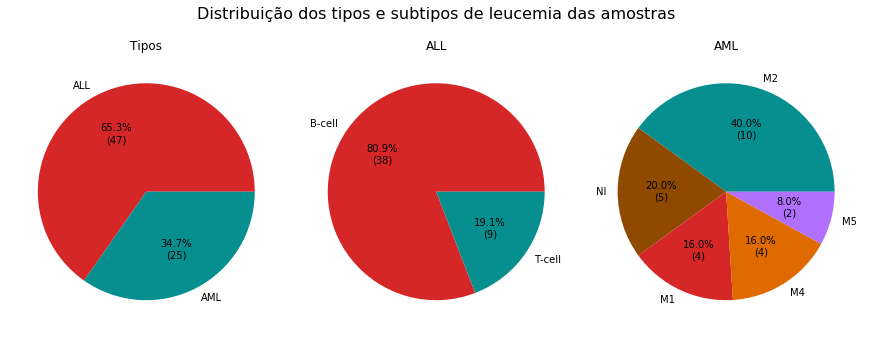

In [5]:
# Função para exibição dos valores absolutos nos gráficos de pizza
def pie_format(pct, allvals):    
    absolute = int(round(pct/100.*np.sum(allvals)))
    return "{:.1f}%\n({:d})".format(pct, absolute)

# Tipos e subtipos
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 5), constrained_layout=True)
class_counts = df_metadata['ALL/AML'].value_counts()
ax[0].pie(class_counts.values, labels=class_counts.index, autopct=lambda x: pie_format(x, class_counts.values), colors=colorize(class_counts.index))
ax[0].set_title('Tipos')
ALL_counts = df_metadata[df_metadata['ALL/AML']=='ALL']['Subtype'].value_counts()
ax[1].pie(ALL_counts.values, labels=ALL_counts.index, autopct=lambda x: pie_format(x, ALL_counts.values), colors=colorize(ALL_counts.index))
ax[1].set_title('ALL')
AML_counts = df_metadata[df_metadata['ALL/AML']=='AML']['Subtype'].value_counts()
ax[2].pie(AML_counts.values, labels=AML_counts.index, autopct=lambda x: pie_format(x, AML_counts.values), colors=colorize(AML_counts.index))
ax[2].set_title('AML')
fig.suptitle('Distribuição dos tipos e subtipos de leucemia das amostras', fontsize=16)
plt.show()

Em relação à distribuição dos metadados restantes, podemos perceber que:
* **BM/PB**: existem muito mais amostras (86,1%) extraídas de medula óssea;
* **Gender**: o gênero encontra-se bastante balanceado, porém muitas amostras (aproximadamente $1/3$) não possuem essa informação;
* **Treatment Response**: a maioria das amostras, 79,2%, não possuem informações sobre a resposta ao tratamento. Daquelas que possuem, a taxa de sucesso encontra-se equilibrada (aproximadamente 50%);
* **Source**: a grande maioria das amostras foi coletada pelo _Dana-Farber Cancer Institute_. Embora a origem de coleta seja uma informação que pareça irrelevante, podemos consultar nos _sites_ das instituições que, diferente do DFCI e do CALGB, o CCG e o St-Jude atendem apenas pacientes infantis. É possível que diferentes faixas etárias apresentem diferenças nos dados; entretanto, como as amostras do CCG e do St-Jude são minoria, não é necessário se preocupar com isso, por enquanto;
* **Date**: por não se tratar de um atributo qualitativo, não faz sentido utilizar um gráfico de pizza para este metadado. Através de um histograma, podemos perceber como a data de coleta se distribui ao longo do tempo, variando de 1980 a 1998, sendo este último ano o que mais houve coleta.

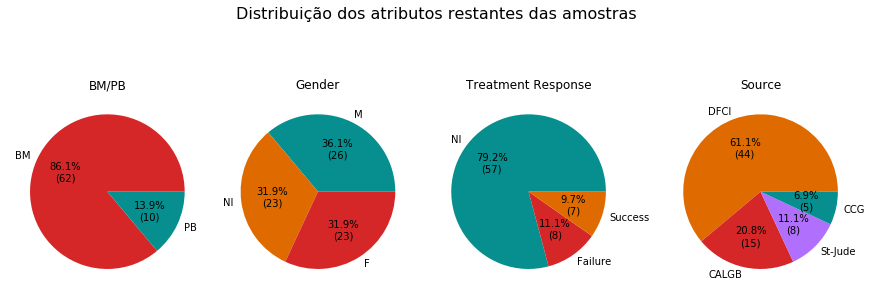

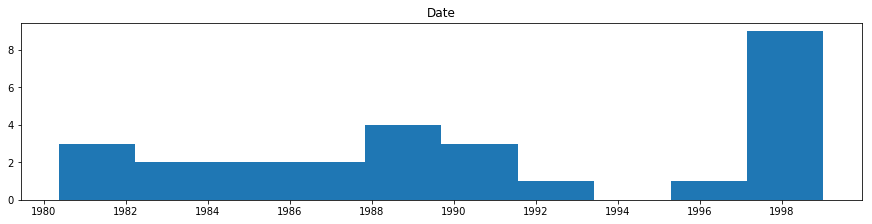

In [6]:
# Atributos restantes
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(12, 5), constrained_layout=True)
for i, column in enumerate(['BM/PB', 'Gender', 'Treatment Response', 'Source']):
    counts = df_metadata[column].value_counts()
    ax[i].pie(counts.values, labels=counts.index, autopct=lambda x: pie_format(x, counts.values), colors=colorize(counts.index))
    ax[i].set_title(column)
fig.suptitle('Distribuição dos atributos restantes das amostras', fontsize=16)
plt.show()

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
fig, ax = plt.subplots(figsize=(12, 3), constrained_layout=True)
ax.hist(pd.to_datetime(df_metadata[df_metadata['Date']!=NOT_INFORMED_VALUES]['Date']).values)
ax.set_title('Date')
plt.show()

---
### Expressão gênica

Após o estudo sobre os metadados, passaremos para uma análise das expressões gênicas das amostras.

Inicialmente, iremos ler os arquivos que contém essa informação, para a base de treino e de teste, armazenando-as em `pandas.DataFrame` diferentes.

Para simular a realidade, trabalharemos da seguinte forma: no contexto de **classificação**, trataremos a base de teste como tendo a classificação das amostras desconhecida, imaginando que ela contém os dados que seriam testados assim que um possível sistema entrasse em produção. Dessa forma, esses dados não serão utilizados no treinamento dos algoritmos, sendo apenas utilizados para a avaliação dos classificadores obtidos com os algoritmos de **classificação**. No contexto de análise de agrupamento, tanto os dados de treinamento quanto os dados de teste serão utilizado para compor uma base única para a aplicação dos algoritmos de **agrupamento**.

Após a leitura dos arquivos, removeremos atributos (colunas) que são irrelevantes para a representação da amostra, mantendo apenas um identificador único para cada gene (*Gene Accession Number*) e seu valor para cada amostra.

A primeira informação extraída é o número de amostras e a dimensionalidade dos dados: **38** amostras de treinamento e **34** de teste, cada uma com **7129** genes.

In [7]:
# Base de treino
df_train = pd.read_csv(os.path.join(DATA_DIR, TRAIN_FILE), sep='\t', index_col=False)
df_train = df_train.drop(columns=['Gene Description']+list(df_train.filter(regex='call*')))
df_train = df_train.set_index('Gene Accession Number').transpose()
df_train = df_train.loc[df_train.index.astype(int).sort_values().astype(str)]

# Base de teste
df_test = pd.read_csv(os.path.join(DATA_DIR, TEST_FILE), sep='\t', index_col=False)
df_test = df_test.drop(columns=['Gene Description']+list(df_test.filter(regex='call*')))
df_test = df_test.set_index('Gene Accession Number').transpose()
df_test = df_test.loc[df_test.index.astype(int).sort_values().astype(str)]

# Quantidades
print('{} amostras de treinamento com {} genes'.format(*df_train.shape))
print('{} amostras de teste com {} genes'.format(*df_test.shape))

38 amostras de treinamento com 7129 genes
34 amostras de teste com 7129 genes


Em seguida, podemos realizar as análises do conteúdo dos dados sob dois pontos de vista: das amostras, verificando como os genes se comportam dentro da amostra, e dos genes, verificando como as amostras se comportam para um determinado gene. A primeira abordagem busca verificar se os valores dos genes são muito diferentes entre si para uma dada amostra, e a segunda se as amostras se comportam de forma diferente para um dado gene.

### Análise do ponto de vista das amostras

#### Medidas descritivas

Aplicaremos algumas medidas descritivas sobre os genes de cada amostra: **média, desvio padrão, mediana, primeiro e terceiro quartil (Q1 e Q3), valores máximos e mínimos**. Em seguida, utilizaremos de recursos visuais para entender melhor sobre as medidas obtidas.

Como temos 38 amostras (lembrando que analisaremos apenas as de treinamento), teremos 38 valores para cada medida.

**Média e desvio padrão**: encontram-se no primeiro gráfico, com a média representada como um ponto e o desvio padrão como uma linha acima e abaixo da média. Podemos perceber que a média varia pouco, com valores entre  492,60 e 954,42, o que indica que os genes tendem a se comportar de forma semelhante dentro da amostra. Entretanto, ao olharmos para o desvio padrão, que varia entre 2264,29 e 2703,73 (de 2,4 a 5,5 vezes a média), podemos perceber como os diversos genes de uma mesma amostra possuem valores diferentes, podendo crescer ou cair muito em relação a média.

**Mediana e quartis**: presentes no segundo gráfico, através de *boxplots* sem *outliers*, e no terceiro gráfico, com *outliers*. Reforçando a informação que a média já havia transmitido, podemos ver que há bastante variação nos valores de genes das amostras. Entretanto, é interessante perceber no gráfico sem *outliers* como o primeiro quartil e a mediana (linhas inferiores e centrais das caixas) variam muito menos entre as amostras do que o terceiro quartil. Isso indica maior padrão entre amostras para os 50% de genes com valores mais baixo. No gráfico com *outliers*, vemos o esperado: muita variação nos dados, com muito genes *outliers* para todas as amostras.

**Valores máximos e mínimos**: Por fim, com os valores máximos e mínimos no quarto gráfico, temos a confirmação final da grande variedade de conteúdo entre os genes. Até então, vimos que os genes possuem valor médio entre 492,60 e 954,42, valor mediano 68,0 e 201,0, com 50% dos genes de cada amostra variando entre -62,0 e 788,0 (menor Q1 e maior Q3). Entretanto, ao olharmos os valores máximos e mínimos, percebemos como o conteúdo dos genes pode variar entre -28400,0 e 61228,0.

,Mean,Std,Q1,Median,Q3,Max,Min
1,641.367092,2264.294361,-21.0,159.0,535.0,31086.0,-19826.0
2,690.246318,2468.814372,-14.0,130.0,488.0,29288.0,-17930.0
3,698.307897,2485.656277,-31.0,177.0,610.0,28056.0,-27182.0
4,600.985271,2340.047428,-33.0,139.0,497.0,31449.0,-23396.0
5,679.532894,2375.895416,8.0,146.0,471.0,29543.0,-10339.0


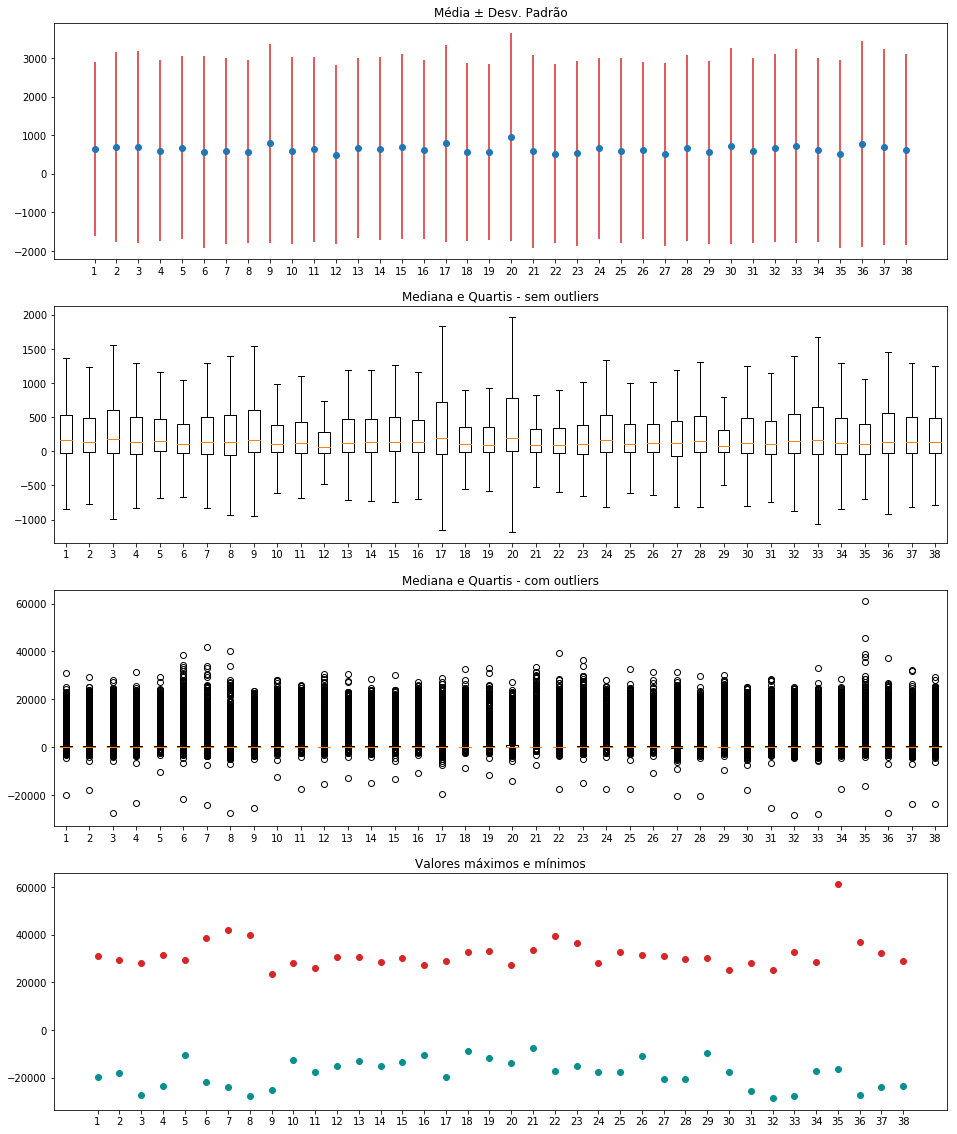

In [8]:
def descriptive_measures(values):
    return pd.Series([
        values.mean(), values.std(),
        values.quantile(0.25), values.median(), values.quantile(0.75),
        values.max(), values.min()
    ], index=['Mean', 'Std', 'Q1', 'Median', 'Q3', 'Max', 'Min'])

# Calcula as medidas descritivas
df_measures = df_train.apply(descriptive_measures, axis=1)
display(df_measures.head(5))

# Exibe as medidas graficamente
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(16, 20))
ax[0].errorbar(df_measures.index, df_measures['Mean'], df_measures['Std'], linestyle='None', marker='o', ecolor='#D62728')
ax[0].set_title('Média ± Desv. Padrão')
ax[1].boxplot([list(row) for _, row in df_train.iterrows()], showfliers=False)
ax[1].set_title('Mediana e Quartis - sem outliers')
ax[2].boxplot([list(row) for _, row in df_train.iterrows()], showfliers=True)
ax[2].set_title('Mediana e Quartis - com outliers')
ax[3].scatter(df_measures.index, df_measures['Max'], color='#D62728')
ax[3].scatter(df_measures.index, df_measures['Min'], color='#078F8F')
ax[3].set_title('Valores máximos e mínimos')
plt.show()

### Correlação entre amostras

Nesta etapa, calcularemos a correlação entre cada par de amostras.

Através do histograma gerado com os valores de correlação, percebemos que todas as amostras possuem uma correlação positiva forte (de 0,7 ou mais). Isso mostra que os valores de um mesmo gene tende a se comportar de maneira relativamente semelhante entre as 38 amostras.

,1,2,3,4,5
1,1.000000,0.914911,0.907057,0.954217,0.931074
2,0.914911,1.000000,0.918627,0.924273,0.926818
3,0.907057,0.918627,1.000000,0.920610,0.894732
4,0.954217,0.924273,0.920610,1.000000,0.954100
5,0.931074,0.926818,0.894732,0.954100,1.000000


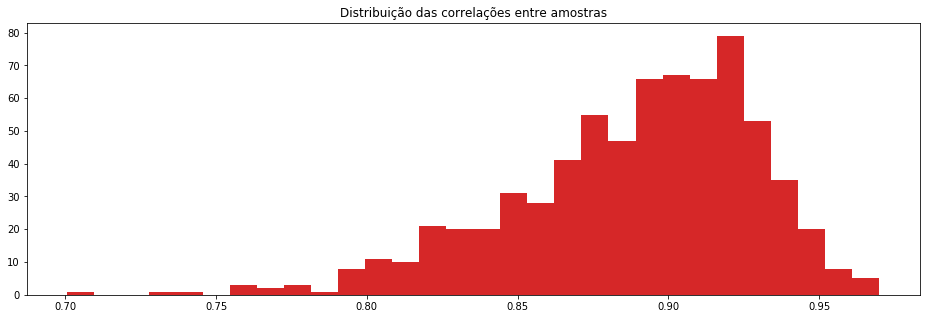

In [9]:
# Calcula a matriz de correlação
correlation_matrix = df_train.transpose().corr()
display(correlation_matrix.iloc[:5, :5])

# Exibe a distribuição
plt.figure(figsize=(16, 5))
plt.hist(correlation_matrix.values[np.tril_indices(len(correlation_matrix), -1)], bins=30, color='#D62728')
plt.title('Distribuição das correlações entre amostras')
plt.show()

### Análise sob a perspectiva dos genes

#### Medidas descritivas

Nesta etapa, aplicaremos algumas medidas descritivas sobre as amostras para cada gene: **média, desvio padrão, mediana, primeiro e terceiro quartil (Q1 e Q3), valores máximos e mínimos**. 

Por termos 7129 genes, teremos 7129 valores para cada medida. Essa alta quantidade de valores dificulta a utilização das técnicas de visualização usadas anteriormente. Por isso, utilizaremos histogramas para visualizar a distribuição de valores de cada medida descritiva.

**Média e desvio padrão**: encontram-se no primeiro e segundo gráfico, respectivamente. Percebemos que a média varia pouco. A grande maioria dos genes tem um valor médio ao redor de zero, com 90% dos genes entre -350 e 2300. Ainda assim, percebemos que certos genes possuem um valor médio extremamente maior (ou menor), de -18168 a 25150. O desvio padrão mostra que não há muitas variações sobre os genes, com 90% deles tendo desvio padrão entre 43 e 1590, valores inferiores a média.

**Mediana e quartis**: a mediana possui um valor bastante semelhante a média, variando no mesmo intervalo. Percebemos também que os quartis não se destoam muito em relação a mediana, indicando pouca variação no valor de um dado gene entre todas as amostras.

**Valores máximos e mínimos**: novamente, os valores máximos e mínimos também se comportam de forma semelhante à média e à mediana, com apenas alguns poucos valores alcançando escalas maiores. Isso evidencia o padrão de comportamento dos genes, assim como a provável existência baixa de _outliers_ nos dados.

,Mean,Std,Q1,Median,Q3,Max,Min
Gene Accession Number,,,,,,,
AFFX-BioB-5_at,-120.868421,109.555656,-138.75,-106.5,-68.25,17.0,-476.0
AFFX-BioB-M_at,-150.526316,75.734507,-205.00,-141.5,-94.75,-20.0,-327.0
AFFX-BioB-3_at,-17.157895,117.686144,-83.25,-43.5,47.25,265.0,-307.0
AFFX-BioC-5_at,181.394737,117.468004,81.25,200.0,279.25,392.0,-36.0
AFFX-BioC-3_at,-276.552632,111.004431,-374.25,-263.0,-188.75,-51.0,-541.0


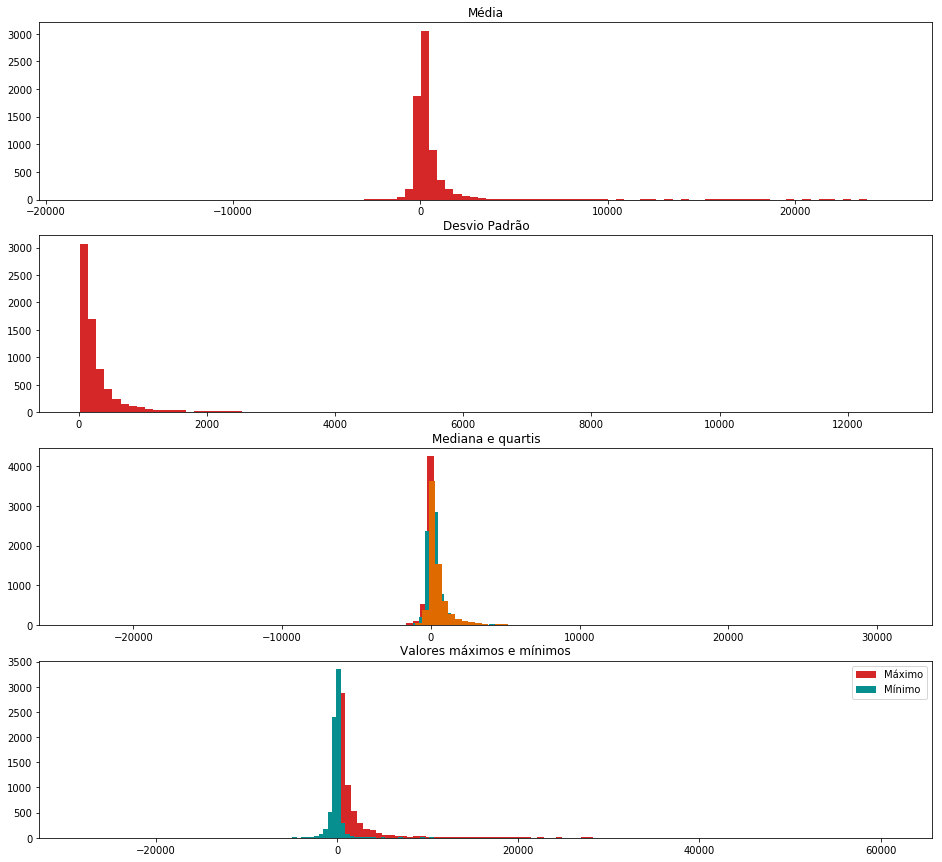

In [10]:
def descriptive_measures(values):
    return pd.Series([
        values.mean(), values.std(),
        values.quantile(0.25), values.median(), values.quantile(0.75),
        values.max(), values.min()
    ], index=['Mean', 'Std', 'Q1', 'Median', 'Q3', 'Max', 'Min'])

# Calcula as medidas descritivas
df_measures = df_train.apply(descriptive_measures, axis=0).transpose()
display(df_measures.head(5))

# Exibe as medidas graficamente
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(16, 15))
ax[0].hist(df_measures['Mean'].values, bins=100, color='#D62728')
ax[0].set_title('Média')
ax[1].hist(df_measures['Std'].values, bins=100, color='#D62728')
ax[1].set_title('Desvio Padrão')
ax[2].hist(df_measures['Q1'].values, bins=100, label='Q1', color='#D62728')
ax[2].hist(df_measures['Median'].values, bins=100, label='Mediana', color='#078F8F')
ax[2].hist(df_measures['Q3'].values, bins=100, label='Q3', color='#DF6B00')
ax[2].set_title('Mediana e quartis')
ax[3].hist(df_measures['Max'].values, bins=100, label='Máximo', color='#D62728')
ax[3].hist(df_measures['Min'].values, bins=100, label='Mínimo', color='#078F8F')
ax[3].legend()
ax[3].set_title('Valores máximos e mínimos')
plt.show()

Mesmo alterando a forma da visualização, o alto volume de genes ainda dificulta a análise. Para aprender mais sobre como os genes se comportam, iremos selecionar alguns genes interessantes: aqueles com valores mais destoantes dos demais.

In [11]:
print('\nGene com a menor média:\t\t\t{}'.format(df_measures['Mean'].idxmin()))
print('Gene com a maior média:\t\t\t{}'.format(df_measures['Mean'].idxmax()))

print('\nGene com o menor desvio padrão:\t\t{}'.format(df_measures['Std'].idxmax()))
print('Gene com o maior desvio padrão:\t\t{}'.format(df_measures['Std'].idxmin()))

print('\nGene com o menor Q1:\t\t\t{}'.format(df_measures['Q1'].idxmax()))
print('Gene com o maior Q1:\t\t\t{}'.format(df_measures['Q1'].idxmin()))

print('\nGene com a menor mediana:\t\t{}'.format(df_measures['Median'].idxmin()))
print('Gene com a maior mediana:\t\t{}'.format(df_measures['Median'].idxmax()))

print('\nGene com o menor Q3:\t\t\t{}'.format(df_measures['Q3'].idxmax()))
print('Gene com o maior Q3:\t\t\t{}'.format(df_measures['Q3'].idxmin()))

print('\nGene com o menor valor mínimo:\t\t{}'.format(df_measures['Min'].idxmin()))
print('Gene com o maior valor mínimo:\t\t{}'.format(df_measures['Min'].idxmax()))

print('\nGene com o menor valor máximo:\t\t{}'.format(df_measures['Max'].idxmin()))
print('Gene com o maior valor máximo:\t\t{}'.format(df_measures['Max'].idxmax()))


Gene com a menor média:			HG2887-HT3031_at
Gene com a maior média:			X17206_at

Gene com o menor desvio padrão:		M25079_s_at
Gene com o maior desvio padrão:		Z70723_at

Gene com o menor Q1:			X17206_at
Gene com o maior Q1:			HG2887-HT3031_at

Gene com a menor mediana:		HG2887-HT3031_at
Gene com a maior mediana:		D49824_s_at

Gene com o menor Q3:			D49824_s_at
Gene com o maior Q3:			HG2887-HT3031_at

Gene com o menor valor mínimo:		HG2887-HT3031_at
Gene com o maior valor mínimo:		X67247_rna1_at

Gene com o menor valor máximo:		HG2887-HT3031_at
Gene com o maior valor máximo:		M25079_s_at


A seleção retornou 6 genes diferentes. Podemos então gerar o _boxplot_ destes genes, para ver como cada um se comporta entre as amostras. 

Adicionalmente, selecionaremos 6 genes aleatórios, para comparar com os 6 interessantes.

Ao fazer isso, percebemos que, como esperado, o conteúdo dos genes entre amostras varia pouco. O _boxplot_ de certos genes, *X17206_at*, *Z70723_at*, *X67247_rna1_at* e *D63390_at*, é extremamente achatado, indicando que seus quartis são bastante próximos (com pouca variação nos dados). Até mesmos os genes com maior variação, não possuem valores tão espalhados ao longo do eixo $y$. Podemos perceber também a baixa ocorrência de _outliers_ (no máximo, 4 casos por gene).

Por outro lado, percebemos que os valores alcançados por genes distintos possui bastante diferença. Para certos genes, como *HG2887-HT3031_at* e *X67247_rna1_at*, por exemplo, não há nenhum valor em comum. O valor máximo para o primeiro gene é -7397, enquanto o valor mínimo para o segundo é 20419. 

Isso reforça o que foi visualizado na análise a nível de amostra e pode ser a conclusão final dessa análise: há pouca diferença nos valores alcançados por um único gene, porém genes diferentes possuem comportamento bastante distinto.

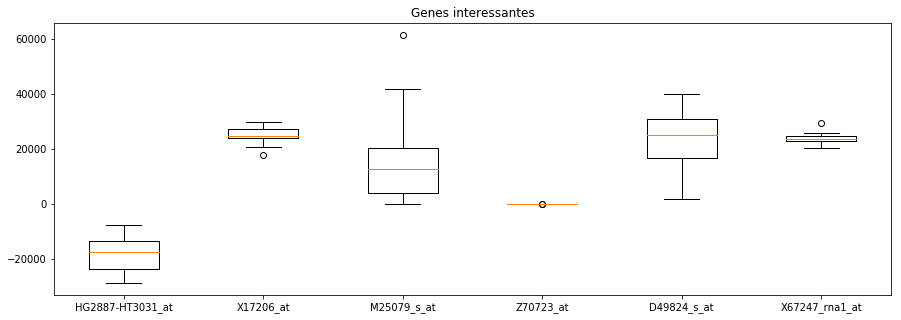

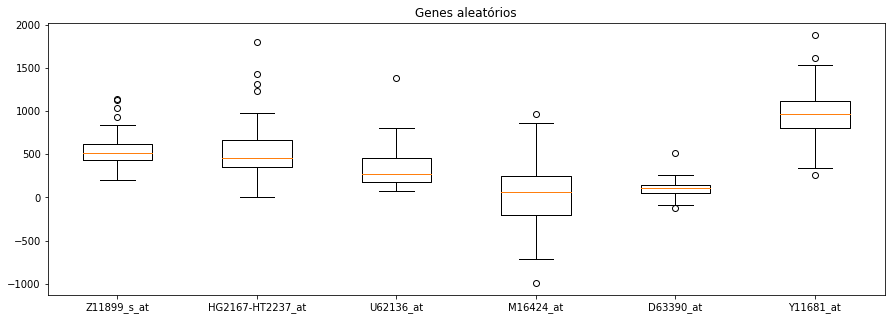

In [12]:
interesting_genes = ['HG2887-HT3031_at', 'X17206_at', 'M25079_s_at', 'Z70723_at', 'D49824_s_at', 'X67247_rna1_at']
plt.figure(figsize=(15,5))
plt.boxplot([df_train[g] for g in interesting_genes], labels=interesting_genes, showfliers=True)
plt.title('Genes interessantes')
plt.show()

random_genes = df_measures.sample(6, random_state=1).index
plt.figure(figsize=(15,5))
plt.boxplot([df_train[g] for g in random_genes], labels=random_genes, showfliers=True)
plt.title('Genes aleatórios')
plt.show()

### Correlação entre genes

Para finalizar a análise, calcularemos a correlação entre genes. De tudo que constatamos até o momento, percebemos que um mesmo gene tende a possuir valores próximos entre cada amostra. Adicionalmente, percebemos que genes diferentes possuem valores bastante diferentes. Dessa forma, podemos supor que não haverá muita correlação entre os genes.

Após gerar o histograma com as correlações, nossa hipótese acima foi validada: a grande maioria dos genes não é correlacionado (coef. de correlação é zero), e poucos possuem correlação forte, seja positiva ou negativa.

Gene Accession Number,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at
Gene Accession Number,,,,,
AFFX-BioB-5_at,1.000000,0.404485,0.125840,0.106268,0.292728
AFFX-BioB-M_at,0.404485,1.000000,0.111541,0.211543,0.213577
AFFX-BioB-3_at,0.125840,0.111541,1.000000,-0.132363,-0.123053
AFFX-BioC-5_at,0.106268,0.211543,-0.132363,1.000000,0.109900
AFFX-BioC-3_at,0.292728,0.213577,-0.123053,0.109900,1.000000


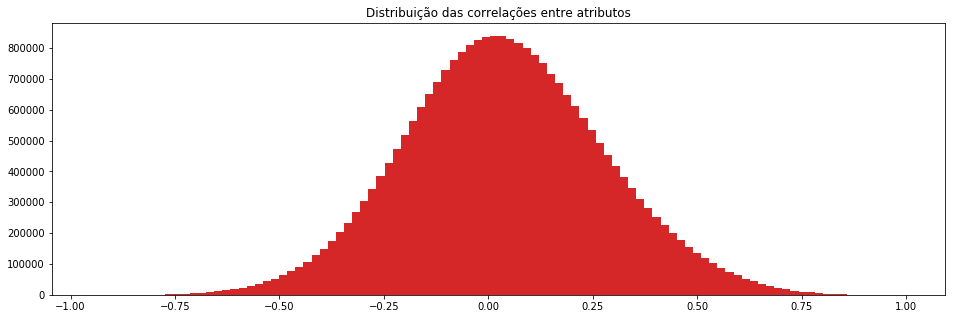

In [13]:
# Calcula a matriz de correlação
correlation_matrix = df_train.corr()
display(correlation_matrix.iloc[:5, :5])

# Exibe a distribuição
plt.figure(figsize=(16, 5))
plt.hist(correlation_matrix.values[np.tril_indices(len(correlation_matrix), -1)], bins=100, color='#D62728')
plt.title('Distribuição das correlações entre atributos')
plt.show()
del correlation_matrix

---
---
# Pré-processamento

Finalizada a análise exploratória, possuímos mais conhecimentos sobre os dados e sabemos possíveis problemas e o que esperar. Desta forma, estamos prontos para trabalhar com eles.

A etapa de pré-processamento é uma das mais importantes - se não, a mais - na hora de resolver um problema com aprendizado de máquina. Erros nessa fase podem comprometer os resultados até de algoritmos estado-da-arte. Por outro lado, um bom tratamento dos dados pode permitir que até mesmo algoritmos simples alcancem resultados ótimos.

Tanto o conhecimento de domínio quanto da caracterização dos dados, como feita anteriormente, são fundamentais para a realização de um pré-processamento adequado. Neste experimento, focaremos principalmente no pré-processamento que considera os conhecimentos dos especialistas de domínio, presentes no artigo original e no trabalho de Dudoit _et al._ [2].

Com esta finalidade, implementaremos 3 tarefas específicas de domínio. São elas:
* **T1**: Aplicar piso de 100 e teto de 16000 no conteúdo das expressões gênicas. Assim, os valores menores que 100 serão transformados para 100, e os maiores que 16000 serão transformados para 16000;
* **T2**: Manter apenas os genes cuja proporção entre seus valores máximo e mínimo sejam maiores que 5 e que a diferença entre esses valores seja superior a 500;
* **T3**: Aplicar logaritmo na base 10 para todos os valores das expressões gênicas.

Antes de implementarmos as três tarefas, iremos nos relembrar de diversos tipos de tratamento dos dados que poderíamos aplicar, embora nem todos sejam necessários ou adequados.

### Eliminação manual de atributos

Já foi realizada no momento de leitura das bases de treinamento, **removendo as colunas Gene Description e call**, que não serão utilizadas. Após esta etapa, ficamos apenas com o identificador dos genes e a expressão gênica de cada amostra, dados suficientes para executarmos os algoritmos de classificação e agrupamento.

### Amostragem de dados

Normalmente, a amostragem é indicada para casos em que a quantidade de amostras é bastante elevada, a ponto de ser inviável ou problemático trabalhar com todas. Em nosso cenário, **temos apenas 72 amostras, o que não é uma quantidade alta de dados**. Pelo contrário, é um número de amostras baixo dependendo do contexto da aplicação. Por este motivo, não é necessário aplicar uma amostragem sobre os dados.

### Redução de dimensionalidade

Podemos reduzir a dimensionalidade das amostras de duas formas. A primeira é através de algoritmos como *SVD* ou *PCA*, que alteram os valores dos dados, mas mantém as informações relevantes. A segunda é através da remoção de atributos, como, por exemplo, através da junção ou remoção de colunas correlacionadas.

A alta dimensionalidade, com 7129 genes, associada ao pequeno número de amostras, é um dos maiores desafios dessa base de dados. Por este motivo, certas técnicas costumam ser utilizadas na análise gênica para que apenas um subconjunto representativo de genes seja selecionado e utilizado no treinamento.

É com este objetivo que aplicaremos a tarefa **T2**. Através dela, serão removidos os genes cuja proporção ou diferença entre seus valores máximos e mínimos sejam baixas, mantendo apenas **3571** genes.

### Balanceamento de dados

O balanceamento de dados é a prática de igualar o número de amostras para diferentes classes. 

Em nosso cenário, temos duas classes diferentes: ALL, com 47 amostras, e AML, com 25 amostras. Para balancear os dados, podemos então remover amostras ALL ou aumentar as amostras AML (duplicando-as ou gerando artificialmente). 

**Remover os dados reduziria ainda mais a base**, que já conta com poucas amostras. **Aumentar os dados envolveria algoritmos adicionais para gerá-los artificialmente, o que foge do escopo deste *notebook***. Adicionalmente, para o problema em que estamos trabalhando, este desbalanceamento não apresentou problemas, como será visto ao longo do experimento.

### Limpeza de dados

Na etapa de limpeza de dados, diversas ações são tomadas sobre os dados para prepará-los. Dados faltantes devem ser preenchidos, e _outliers_ removidos.

Como **não possuímos dados faltantes na base**, essa etapa pode ser ignorada.

A remoção de _outlier_ seria possível, através de métodos simples (utilizando os quartis e a amplitude interquartil) ou complexos (como os métodos *Local Outlier Factor* ou *Isolation Forest*, [implementados pela biblioteca scikit-learn](https://scikit-learn.org/stable/modules/outlier_detection.html)). Porém, como já iremos aplicar outras tarefas específicas de domínio que transformarão o conteúdo dos dados (como **T1** e **T3**), **não faz sentido aplicar técnicas com esta finalidade**. Pode ser que a detecção de câncer se dê exatamente pela existência de *outliers*, e tratá-los seria prejudicial para o problema.

### Transformação de dados

A etapa de transformação dos dados corresponde em alterar a escala dos mesmos. 

Vimos na análise exploratória que as expressões gênicas podem alcançar valores de genes bastante diferentes entre si. Dessa forma, transformar os dados pode ajudar na resolução dos problemas. Entretanto, é importante que isso seja feito com base no conhecimento específico de domínio, para que não seja feitas alterações que prejudiquem os dados.

Com esta finalidade, aplicaremos as tarefas **T1** e **T3**, que irão, respectivamente, eliminar valores muito baixos ou elevados, e mudar drasticamente a escala dos dados.

### Implementação das tarefas de domínio

Como mencionado anteriormente, iremos aplicar três tarefas específicas de domínio utilizadas em trabalhos da área [2, 3]. São elas:

* **T1**: Aplicar piso de 100 e teto de 16000 no conteúdo das expressões gênicas. Assim, os valores menores que 100 serão transformados para 100, e os maiores que 16000 serão transformados para 16000;
* **T2**: Manter apenas os genes cuja proporção entre seus valores máximo e mínimo sejam maiores que 5 e que a diferença entre esses valores seja superior a 500;
* **T3**: Aplicar logaritmo na base 10 para todos os valores das expressões gênicas.

Para isso, serão implementadas funções que recebem as bases de treino e teste e aplicam as alterações descritas em cada tarefa.

**Atenção**: para simular um cenário real, **é muito importante que a base de teste não influencie no pré-processamento**. Dessa forma, apenas a base de treinamento pode ser utilizada na hora de tomar decisões, que serão aplicadas na de teste. Das tarefas aqui utilizadas, **T2** deve escolher genes que serão mantidos de acordo com seus conteúdos. Essa escolha deve ser realizada observando apenas os valores da base de treinamento, para só depois, com os devidos genes selecionados, ser aplicada na base de teste (linhas `8 a 12` do código abaixo).

In [14]:
def task_1(df_train, df_test=None):
    df_train = df_train.clip(lower=100, upper=16000)
    if df_test is not None:
        df_test = df_test.clip(lower=100, upper=16000)
    return df_train, df_test

def task_2(df_train, df_test=None):
    max_min_prop = ((df_train.max()/df_train.min()).abs()>5) & ((df_train.max()-df_train.min())>500)
    remaining = max_min_prop[max_min_prop].index
    df_train = df_train[remaining]
    if df_test is not None:
        df_test = df_test[remaining]
    return df_train, df_test

def task_3(df_train, df_test=None):
    df_train = np.log10(df_train)
    if df_test is not None:
        df_test = np.log10(df_test)
    return df_train, df_test

df_all = pd.concat([df_train, df_test])
print('Base original possui {} genes'.format(df_all.shape[1]))
df_all_pp, _ = task_3(*task_2(*task_1(df_all)))
print('Após tarefas, base possui {} genes'.format(df_all_pp.shape[1]))

Base original possui 7129 genes
Após tarefas, base possui 3571 genes


### Múltiplas bases de dados

Para analisar o impacto que diferentes pré-processamentos podem causar nos resultados finais, iremos gerar duas bases de dados.

A primeira, **PP1**, possuirá as 3 tarefas, aplicadas sequencialmente. A segunda, **PP2**, possuirá apenas a tarefa 2, de forma que haja uma redução de dimensionalidade nos dados, mas que não seja feita nenhuma transformação.

In [15]:
def pp1(df_train, df_test=None):
    df_train, df_test = task_3(*task_2(*task_1(df_train, df_test)))
    return df_train if df_test is None else (df_train, df_test)

def pp2(df_train, df_test=None):
    df_train, df_test = task_2(df_train, df_test)
    return df_train if df_test is None else (df_train, df_test)

---
# Problema de classificação

Nesta fase do experimento, aplicaremos algoritmos de classificação para previsão dos tipos e subtipos de leucemia.

### A) Classificação de tipos de leucemia

Inicialmente, iremos trabalhar com o problema de classificação do **tipo** da leucemia. Iremos treinar diferentes algoritmos de classificação com as amostras de treinamento, para depois prever o tipo de leucemia das amostras de teste e avaliar nossas previsões.

As amostras podem ter dois rótulos diferentes, **ALL** e **AML**. Inicialmente iremos montar nossos vetores de rótulos, com conteúdo 0 para amostras ALL, e 1 para amostras AML.

Nesse caso, a escolha dos rótulos se deu arbitrariamente, pois não há uma classe "positiva" (as duas são igualmente importantes de serem descobertas). Em cenários diferentes, como, por exemplo, a detecção da existência de câncer, o rótulo 1 deve, por convenção, ser adotado ao caso em que se deseja descobrir.

In [16]:
class_encoder = {'ALL': 0, 'AML': 1}
y_train = df_metadata.loc[df_train.index]['ALL/AML'].replace(class_encoder).values.astype(int)
y_test = df_metadata.loc[df_test.index]['ALL/AML'].replace(class_encoder).values.astype(int)
class_encoder = ['ALL', 'AML']

Em seguida, iremos definir os modelos que queremos avaliar. Para parametrizar os modelos, iremos aplicar uma busca em grade (*grid search*), então precisamos definir também quais parâmetros serão variados, e quais valores serão testados.

Iremos aplicar os seguintes algoritmos:

**K-vizinhos mais próximos (KNN)**, implementado em `sklearn.neighbors.KNeighborsClassifier`. Iremos variar o número de vizinhos (parâmetro `n_neighbors`) para todos os números ímpares entre $[3, 11]$

**Regressão Logística**, implementada em `sklearn.linear_model.LogisticRegression`. Como parâmetro de regularização (`C`), utilizaremos o valor $10^p$, com $p$ variando entre $[-3, 1]$.

**Naive-Bayes**, implementada em `sklearn.naive_bayes.GaussianNB`. Iremos alterar o limite de variância para cálculo de estabilidade (parâmetro `var_smoothing`), em $\{10^{-15}, 10^{-12}, 10^{-9}, 10^{-6}, 10^{-3}\}$.

**SVM Linear**, implementada em `sklearn.svm.LinearSVC`. Iremos alterar o parâmetro de regularização, com os mesmos valores daa Regressão Logística.

**Floresta aleatória**, implementada em `sklearn.ensemble.RandomForestClassifier`. Testaremos diferentes quantidade de árvore (`n_estimators`), entre $[50,150]$ com passo de 25.

A escolha dos métodos se deu por cada um realizar o treinamento com abordagens diferentes (distância, otimização, probabilidade e árvores de decisão).

**Nota sobre a implementação**: alguns métodos receberão também o parâmetro `random_state` para garantir a reproducibilidade.

In [17]:
models = [
    ('KNN', KNeighborsClassifier, {'n_neighbors': [3, 5, 7, 9, 11]}),
    ('Reg. Logística', LogisticRegression, {'C': [1e-3, 1e-2, 1e-1, 1, 10], 'random_state': [1]}),
    ('Naive-Bayes', GaussianNB, {'var_smoothing': [1e-15, 1e-12, 1e-9, 1e-6, 1e-3]}),
    ('SVM', LinearSVC, {'C': [1e-3, 1e-2, 1e-1, 1, 10], 'random_state': [1]}),
    ('Floresta aleatória', RandomForestClassifier, {'n_estimators': [50, 75, 100, 125, 150], 'random_state': [1]})
]

Utilizaremos _grid search_ para a parametrização e validação cruzada com _k-folds_ para treinamento e validação dos algoritmos. Espera-se que o leitor tenha visto estas técnicas nos _notebooks_ passados, então as mesmas não serão explicadas com profundidade.

**Atenção**: na validação cruzada com *k-folds*, os parâmetros serão testados e os modelos executados k vezes, em diferentes partições da base. Para cada uma das k iterações, um subconjunto de dados diferente será selecionado como teste, com os demais dados sendo utilizados como treinamento. Novamente, é importante se atentar para que **a base de teste da iteração atual não influencie no pré-processamento**. Assim, a etapa de pré-processamento não deve ser feita anteriormente, mas sim diversas vezes ao longo das iterações. Para cada *fold*, a base de treinamento deve ser utilizada para as decisões do pré-processamento, que serão aplicadas sobre a base de teste.

Para realizar o experimento, implementaremos três funções diferentes, que serão utilizadas nesse momento e futuramente, na classificação de subtipos. São elas:

`grid_search_cross_validation`: recebe uma lista de modelos (`models`), a base de dados de entrada (`X`), um vetor de rótulos de saída (`y`) e o número de folds (`n_folds`). Faz validação _k-fold_ sobre os dados (neste experimento, utilizaremos $k=4$) e retorna, para cada base (Original, PP1 e PP2) e cada modelo, qual o melhor parâmetro escolhido através da maximização da acurácia (`best_params`), e qual a acurácia máxima alcançada (`best_scores`), em formato de `dict`.

`run_on_test_dataset`: recebe as bases de treino e teste (`X_train` e `X_test`), assim como suas saídas (`y_train` e `y_test`), uma lista de modelos (`models`) e o melhor parâmetro para cada um deles (`best_params`). Treina cada modelo com os parâmetros informados, testa sobre a base de teste, e retorna algumas métricas de avaliação da predição (acurácia, precisão, revocação e f-medida).

`transform_results_in_multilabel`: recebe as métricas calculadas (`metrics_results`) e uma lista com as classes ordenadas de acordo com o rótulo atribuído (`class_encoder`). Converte o formato dos dados para as métricas de avaliação que possuem mais de um valor de acordo com a classe escolhida como positiva (precisão, revocação e f-medida), gerando um `pandas.DataFrame` com múltiplas colunas por classe.

**Nota sobre a implementação**: embora a biblioteca `scikit-learn` possua uma função pronta para *grid-search* com *k-folds*, em `sklearn.model_selection.GridSearchCV`, a implementação possui uma deficiência. Nela, não é possível passar as tarefas de pré-processamento que devem ser aplicadas sobre as bases. Aplicar o pré-processamento nas bases antes da chamada da função geraria o problema de deixar que amostras de teste (já que toda a base de treino será usada como teste pelo *k-fold*) interfiram no pré-processamento.

In [18]:
import warnings
warnings.filterwarnings('ignore')

def grid_search_cross_validation(models, X, y, n_folds, verbose=True):
    # Cria o dicionário para armazenar resultados
    results = dict()    
    # Separa e percorre os folds
    kfold = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=50)
    for kf, (train_index, test_index) in enumerate(kfold.split(X, y), start=1):                
        fold_X_train, fold_X_test = X.iloc[train_index], X.iloc[test_index]                
        y_train, y_test = y[train_index], y[test_index]
        # Trata e as bases de dados
        datasets = [
            ('Original', fold_X_train, fold_X_test),
            ('PP1', *pp1(fold_X_train, fold_X_test)),
            ('PP2', *pp2(fold_X_train, fold_X_test))
        ]
        # Percorre os modelos
        for model_name, model, param_grid in models:
            if model_name not in results:
                results[model_name] = dict()                
            # Percorre as bases de dados
            for dataset_name, X_train, X_test in datasets:                                
                if dataset_name not in results[model_name]:
                    results[model_name][dataset_name] = dict()
                # Exibe o progresso
                if verbose:
                    print('Fold {}/{} - {} - Base {}'.format(kf, n_folds, model_name, dataset_name))
                # Percorre os parametros
                for params in ParameterGrid(param_grid):
                    if str(params) not in results[model_name][dataset_name]:
                        results[model_name][dataset_name][str(params)] = list()
                    # Realiza o treinamento e salva a acurácia da predição
                    clf = model(**params)
                    clf.fit(X_train, y_train)
                    y_pred = clf.predict(X_test)
                    results[model_name][dataset_name][str(params)].append(accuracy_score(y_test, y_pred))
    # Calcula a acurácia final e salva melhor combinação de parâmetros e resultado
    best_params = dict()
    best_scores = dict()
    for model_name, dataset_results in results.items():
        best_params[model_name] = dict()
        best_scores[model_name] = dict()
        for dataset_name, param_results in dataset_results.items():
            best_params[model_name][dataset_name] = None
            best_scores[model_name][dataset_name] = 0
            for params, scores in param_results.items():
                mean_score = np.mean(scores)
                if mean_score > best_scores[model_name][dataset_name]:
                    best_params[model_name][dataset_name] = literal_eval(params)
                    best_scores[model_name][dataset_name] = mean_score
    return best_params, best_scores


def run_on_test_dataset(X_train, y_train, X_test, y_test, models, best_params):
    # Monta dicionario para salvar resultados
    metrics_results = {metric: dict() for metric in ['Acc', 'Prec', 'Rec', 'F1']}
    # Trata as bases de dados
    datasets = [
        ('Original', X_train, X_test),
        ('PP1', *pp1(X_train, X_test)),
        ('PP2', *pp2(X_train, X_test))
    ]    
    # Percorre os modelos
    for model_name, model, _ in models:
        for metric in ['Acc', 'Prec', 'Rec', 'F1']:
            metrics_results[metric][model_name] = dict()
        # Percorre as bases de dados
        for dataset_name, X_train, X_test in datasets:
            # Treina o modelo e gera a predição
            clf = model(**best_params[model_name][dataset_name])
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            # Calcula as métricas
            metrics_results['Acc'][model_name][dataset_name] = accuracy_score(y_test, y_pred)            
            metrics_results['Prec'][model_name][dataset_name] = precision_score(y_test, y_pred, average=None)
            metrics_results['Rec'][model_name][dataset_name] = recall_score(y_test, y_pred, average=None)
            metrics_results['F1'][model_name][dataset_name] = f1_score(y_test, y_pred, average=None)
    return metrics_results

def transform_results_in_multilabel(metrics_results, class_encoder):
    multilabel_results = dict()
    for model_name, dataset_results in metrics_results.items():
        for c in range(len(class_encoder)):
            multilabel_results[(model_name, class_encoder[c])] = dict()
            for dataset_name, results in dataset_results.items():
                multilabel_results[(model_name, class_encoder[c])][dataset_name] = results[c]
    return multilabel_results

Executaremos os algoritmos para recuperar os melhores parâmetros...

In [19]:
best_params, best_scores = grid_search_cross_validation(models, df_train, y_train, 4)

Fold 1/4 - KNN - Base Original
Fold 1/4 - KNN - Base PP1
Fold 1/4 - KNN - Base PP2
Fold 1/4 - Reg. Logística - Base Original
Fold 1/4 - Reg. Logística - Base PP1
Fold 1/4 - Reg. Logística - Base PP2
Fold 1/4 - Naive-Bayes - Base Original
Fold 1/4 - Naive-Bayes - Base PP1
Fold 1/4 - Naive-Bayes - Base PP2
Fold 1/4 - SVM - Base Original
Fold 1/4 - SVM - Base PP1
Fold 1/4 - SVM - Base PP2
Fold 1/4 - Floresta aleatória - Base Original
Fold 1/4 - Floresta aleatória - Base PP1
Fold 1/4 - Floresta aleatória - Base PP2
Fold 2/4 - KNN - Base Original
Fold 2/4 - KNN - Base PP1
Fold 2/4 - KNN - Base PP2
Fold 2/4 - Reg. Logística - Base Original
Fold 2/4 - Reg. Logística - Base PP1
Fold 2/4 - Reg. Logística - Base PP2
Fold 2/4 - Naive-Bayes - Base Original
Fold 2/4 - Naive-Bayes - Base PP1
Fold 2/4 - Naive-Bayes - Base PP2
Fold 2/4 - SVM - Base Original
Fold 2/4 - SVM - Base PP1
Fold 2/4 - SVM - Base PP2
Fold 2/4 - Floresta aleatória - Base Original
Fold 2/4 - Floresta aleatória - Base PP1
Fold 2/

Após a execução dos métodos de aprendizado, iremos ver quais foram as melhores acurácias médias alcançados nas bases de teste do *k-fold*, assim como os parâmetros que geraram estes resultados.

In [20]:
display(pd.DataFrame(best_scores).round(3))
display(pd.DataFrame(best_params))

,KNN,Reg. Logística,Naive-Bayes,SVM,Floresta aleatória
Original,0.919,0.972,0.972,0.972,0.864
PP1,0.975,1.000,0.944,1.000,0.972
PP2,0.972,0.972,1.000,0.972,0.917


,KNN,Reg. Logística,Naive-Bayes,SVM,Floresta aleatória
Original,{'n_neighbors': 3},"{'C': 0.001, 'random_state': 1}",{'var_smoothing': 1e-15},"{'C': 0.001, 'random_state': 1}","{'n_estimators': 125, 'random_state': 1}"
PP1,{'n_neighbors': 3},"{'C': 1, 'random_state': 1}",{'var_smoothing': 0.001},"{'C': 0.01, 'random_state': 1}","{'n_estimators': 125, 'random_state': 1}"
PP2,{'n_neighbors': 3},"{'C': 0.001, 'random_state': 1}",{'var_smoothing': 0.001},"{'C': 0.001, 'random_state': 1}","{'n_estimators': 75, 'random_state': 1}"


Como podemos ver, os algoritmos, de maneira geral, conseguiram boas acurácias, chegando até a acertar 100% dos casos pasa alguns algoritmos e bases de dados. Entretanto, mesmo que improvável por termos usado *k-fold*, pode haver superajustamento. 

Para descartar definitivamente essa possibilidade, verificaremos como os algoritmos se comportam sobre a base de teste, até então nunca vista pelos métodos.

Com as métricas calculadas, podemos analisá-las individualmente, e ter uma visão sobre os algoritmos.

In [21]:
test_results = run_on_test_dataset(df_train, y_train, df_test, y_test, models, best_params)

##### Acurácia

Novamente, a acurácia mostrou que os algoritmos estão com alto poder de predição, acertando até 97,10% das amostras para os algoritmos KNN, Regressão Logística e SVM. Isso mostra como é possível sim descobrir o tipo de leucemia utilizando microarranjos de DNA, hipótese defendida pelos autores do artigo.

Adicionalmente, é interessante percebermos como o pré-processamento e os algoritmos influenciaram os resultados: o KNN, um dos métodos mais simples, foi um dos piores algoritmo para a base original. Entretanto, quando aplicado sobre as bases pré-processadas, foi um dos que alcançou o melhor resultado, junto com a Regressão Logística e o SVM. Para os demais algoritmos, a base original, em alguns casos, se saiu igual ou tão boa quanto as bases tratadas. 

Comparando a base PP1 com PP2, vemos como bases geradas com tratamentos diferentes podem gerar resultados diferentes de acordo com o algoritmo. Não houve uma base que se saiu claramente superior que a outra, tendo cada uma apresentado melhores resultados de acordo com o método aplicado.

In [22]:
display(pd.DataFrame(test_results['Acc']).round(3))

,KNN,Reg. Logística,Naive-Bayes,SVM,Floresta aleatória
Original,0.882,0.971,0.912,0.971,0.794
PP1,0.971,0.971,0.941,0.971,0.882
PP2,0.971,1.000,0.824,0.971,0.853


##### Precisão para cada classe

A precisão da classe corresponde à quantidade de predições para uma dada classe que estavam certas.

Podemos ver como, em muitos casos, 100% das previsões do método para uma determinada classe estavam corretas. Isso pode significar um bom resultado, mas devemos olhar a revocação em conjunto para termos uma visão completa do funcionamento do algoritmo.

Também podemos perceber como a precisão muda significativamente de acordo com a base. Certos algoritmos, como o Naive-Bayes e o SVM, apresentaram maior facilidade em encontrar amostras ALL para as bases Original e PP2, e mais facilidade para amostras AML na base PP1.

Para aprendermos mais sobre as análises, vamos focar nos resultados obtidos pelo método de Floresta Aleatória nas diferentes bases, comparando a precisão com a revocação...

In [23]:
display(pd.DataFrame(transform_results_in_multilabel(test_results['Prec'], class_encoder)).round(3))

KNN      Reg. Logística        Naive-Bayes           SVM         \
            ALL  AML            ALL    AML         ALL    AML    ALL    AML   
Original  0.833  1.0          1.000  0.933       0.947  0.867  1.000  0.933   
PP1       0.952  1.0          0.952  1.000       0.909  1.000  0.952  1.000   
PP2       0.952  1.0          1.000  1.000       0.938  0.722  1.000  0.933   

         Floresta aleatória       
                        ALL  AML  
Original              0.741  1.0  
PP1                   0.833  1.0  
PP2                   0.800  1.0

##### Revocação

A revocação corresponde ao número de amostras pertencentes a uma classe que foram corretamente previstas.

Novamente, temos casos em que 100% das amostras de uma classe foram encontradas, e podemos perceber como o pré-processamento exerce grande impacto sobre o resultado final.

Observando os resultados obtidos pela Floresta Aleatória, podemos perceber que olhar só a precisão ou a revocação pode gerar _insights_ errados: no caso acima, o método alcançou precisão de 100% para a classe AML em todas as bases, e uma baixa precisão para amostras ALL, o que pode indicar que o método sabe reconhecer muito bem uma amostra AML, independente da base. Entretanto, ao olharmos a revocação, vemos que o que está acontecendo é que o método prevê a classe ALL com muito mais frequência, alcançando 100% de revocação independente da base. Mais do que isso, mostra como o método está encontrando poucas das amostras reais de AML (apenas metade delas na base Original), indo contra a suposição que fizemos inicialmente.

In [24]:
display(pd.DataFrame(transform_results_in_multilabel(test_results['Rec'], class_encoder)).round(3))

KNN        Reg. Logística        Naive-Bayes          SVM         \
          ALL    AML            ALL    AML         ALL    AML   ALL    AML   
Original  1.0  0.714           0.95  1.000        0.90  0.929  0.95  1.000   
PP1       1.0  0.929           1.00  0.929        1.00  0.857  1.00  0.929   
PP2       1.0  0.929           1.00  1.000        0.75  0.929  0.95  1.000   

         Floresta aleatória         
                        ALL    AML  
Original                1.0  0.500  
PP1                     1.0  0.714  
PP2                     1.0  0.643

##### F-Medida

Por fim, a F-Medida traz uma média harmônica entre a precisão e a revocação, equilibrando as duas e contornando o problema mencionado acima. Através dela, é possível ver qual a qualidade do método em acertar uma determinada classe.

Com ela, percebemos que métodos que obtiveram a mesma acurácia não realizaram as mesmas previsões, obrigatoriamente. SVM para as bases Original e PP1 alcançou a mesma acurácia (97,1%), mas ao analisarmos a F-Medida, vemos que com a base Original, o método tende a acertar um pouco menos as amostras ALL quando comparado com a execução sobre a base PP1.

In [25]:
display(pd.DataFrame(transform_results_in_multilabel(test_results['F1'], class_encoder)).round(3))

KNN        Reg. Logística        Naive-Bayes           SVM         \
            ALL    AML            ALL    AML         ALL    AML    ALL    AML   
Original  0.909  0.833          0.974  0.966       0.923  0.897  0.974  0.966   
PP1       0.976  0.963          0.976  0.963       0.952  0.923  0.976  0.963   
PP2       0.976  0.963          1.000  1.000       0.833  0.813  0.974  0.966   

         Floresta aleatória         
                        ALL    AML  
Original              0.851  0.667  
PP1                   0.909  0.833  
PP2                   0.889  0.783

### B) Classificação de subtipos de leucemia

Em seguida, iremos verificar a capacidade dos algoritmos de prever os subtipos das amostras.

Embora amostras do tipo AML possuam diversos subtipos diferentes (M1, M2, M4 e M5), trataremos os dados da mesma forma que no artigo de Golub *et al.* [3]: classificando-os como "ALL do tipo B", "ALL do tipo T" e "AML". Dessa forma, nosso problema passará a ser uma classificação multi-classe, com três rótulos possíveis.

In [26]:
class_encoder = {'B-cell': 0, 'T-cell': 1, 'M1': 2, 'M2': 2, 'M4': 2, 'M5': 2, 'NI': 2}
y_train = df_metadata.loc[df_train.index]['Subtype'].replace(class_encoder).values.astype(int)
y_test = df_metadata.loc[df_test.index]['Subtype'].replace(class_encoder).values.astype(int)
class_encoder = ['B-cell', 'T-cell', 'AML']

Da mesma maneira que anteriormente, encontraremos os melhores parâmetros...

In [27]:
best_params, best_scores = grid_search_cross_validation(models, df_train, y_train, 4)

Fold 1/4 - KNN - Base Original
Fold 1/4 - KNN - Base PP1
Fold 1/4 - KNN - Base PP2
Fold 1/4 - Reg. Logística - Base Original
Fold 1/4 - Reg. Logística - Base PP1
Fold 1/4 - Reg. Logística - Base PP2
Fold 1/4 - Naive-Bayes - Base Original
Fold 1/4 - Naive-Bayes - Base PP1
Fold 1/4 - Naive-Bayes - Base PP2
Fold 1/4 - SVM - Base Original
Fold 1/4 - SVM - Base PP1
Fold 1/4 - SVM - Base PP2
Fold 1/4 - Floresta aleatória - Base Original
Fold 1/4 - Floresta aleatória - Base PP1
Fold 1/4 - Floresta aleatória - Base PP2
Fold 2/4 - KNN - Base Original
Fold 2/4 - KNN - Base PP1
Fold 2/4 - KNN - Base PP2
Fold 2/4 - Reg. Logística - Base Original
Fold 2/4 - Reg. Logística - Base PP1
Fold 2/4 - Reg. Logística - Base PP2
Fold 2/4 - Naive-Bayes - Base Original
Fold 2/4 - Naive-Bayes - Base PP1
Fold 2/4 - Naive-Bayes - Base PP2
Fold 2/4 - SVM - Base Original
Fold 2/4 - SVM - Base PP1
Fold 2/4 - SVM - Base PP2
Fold 2/4 - Floresta aleatória - Base Original
Fold 2/4 - Floresta aleatória - Base PP1
Fold 2/

Vamos visualizar as melhores acurácias médias encontradas para cada base de teste do *k-fold*, assim como os parâmetros que alcançaram esses valores.

In [28]:
display(pd.DataFrame(best_scores).round(3))
display(pd.DataFrame(best_params))

,KNN,Reg. Logística,Naive-Bayes,SVM,Floresta aleatória
Original,0.867,0.975,1.000,0.947,0.947
PP1,1.000,1.000,0.922,1.000,0.975
PP2,0.894,0.975,0.972,0.947,0.950


,KNN,Reg. Logística,Naive-Bayes,SVM,Floresta aleatória
Original,{'n_neighbors': 3},"{'C': 10, 'random_state': 1}",{'var_smoothing': 0.001},"{'C': 0.001, 'random_state': 1}","{'n_estimators': 100, 'random_state': 1}"
PP1,{'n_neighbors': 3},"{'C': 0.1, 'random_state': 1}",{'var_smoothing': 1e-15},"{'C': 0.001, 'random_state': 1}","{'n_estimators': 75, 'random_state': 1}"
PP2,{'n_neighbors': 3},"{'C': 0.001, 'random_state': 1}",{'var_smoothing': 0.001},"{'C': 0.001, 'random_state': 1}","{'n_estimators': 50, 'random_state': 1}"


Novamente, as acurácias trouxeram resultados promissores! Devemos então aplicar os métodos sobre a base de teste.

In [29]:
test_results = run_on_test_dataset(df_train, y_train, df_test, y_test, models, best_params)

##### Acurácia

Alcançando altos valores para a acurácia, os resultados mostram que é possível descobrir o tipo e o subtipo de amostras de leucemia através de algoritmos de classificação sobre microarranjos de DNA.

Alguns dos resultados obtidos se comportaram bastante semelhantes ao problema anterior de classificação do tipo de leucemia, como é o caso da Regressão Logística. Entretanto, outros métodos mudaram de forma mais evidente. 

É interessante perceber o comportamento do SVM, que antes alcançou 97,1% de acurácia para todas as bases. Para o problema de detecção de subtipo, os resultados entre as bases foram diferentes, evidenciando o impacto do pré-processamento. Adicionalmente, mesmo se tratando de um problema mais complexo do que o de detecção de tipo, ele foi capaz de atingir uma acurácia para a base PP2 ainda maior do que antes, acertando 100% das amostras.

In [30]:
display(pd.DataFrame(test_results['Acc']).round(3))

,KNN,Reg. Logística,Naive-Bayes,SVM,Floresta aleatória
Original,0.853,0.971,0.853,0.941,0.912
PP1,0.971,0.971,0.912,0.971,0.941
PP2,0.971,1.000,0.824,1.000,0.912


##### Precisão

Através da precisão, podemos ver como métodos que alcançam bons resultados de acurácia não serão, necessariamente, precisos para todas as classes. Como exemplo, temos o Naive-Bayes para a base PP1, que alcançou 91,2% de acurácia, mas 0% de precisão para o subtipo *T-Cell*.

In [31]:
display(pd.DataFrame(transform_results_in_multilabel(test_results['Prec'], class_encoder)).round(3))

KNN             Reg. Logística               Naive-Bayes         \
         B-cell T-cell  AML         B-cell T-cell    AML      B-cell T-cell   
Original  0.792    0.0  1.0            1.0    0.0  0.933       1.000    1.0   
PP1       0.950    1.0  1.0            1.0    0.0  0.933       0.864    0.0   
PP2       0.950    1.0  1.0            1.0    1.0  1.000       0.933    1.0   

                   SVM               Floresta aleatória                
            AML B-cell T-cell    AML             B-cell T-cell    AML  
Original  0.737    1.0    1.0  0.875              0.905    0.0  0.923  
PP1       1.000    1.0    0.0  0.933              0.950    0.0  0.929  
PP2       0.722    1.0    1.0  1.000              0.950    0.0  0.923

##### Revocação

Da mesma forma que a precisão, a revocação mostra como métodos com alta acurácia podem apresentar baixas revocações para determinadas classes. O Naive-Bayes com PP1 é, novamente, um bom exemplo, acertando 0% das amostras de *T-cell*, e apresentando um resultado oposto ao da precisão para os subtipos *B-cell* e *AML* na base Original.

In [32]:
display(pd.DataFrame(transform_results_in_multilabel(test_results['Rec'], class_encoder)).round(3))

KNN               Reg. Logística             Naive-Bayes         \
         B-cell T-cell    AML         B-cell T-cell  AML      B-cell T-cell   
Original    1.0    0.0  0.714            1.0    0.0  1.0       0.737    1.0   
PP1         1.0    1.0  0.929            1.0    0.0  1.0       1.000    0.0   
PP2         1.0    1.0  0.929            1.0    1.0  1.0       0.737    1.0   

                   SVM             Floresta aleatória                
            AML B-cell T-cell  AML             B-cell T-cell    AML  
Original  1.000  0.895    1.0  1.0                1.0    0.0  0.857  
PP1       0.857  1.000    0.0  1.0                1.0    0.0  0.929  
PP2       0.929  1.000    1.0  1.0                1.0    0.0  0.857

##### F-Medida

E finalmente, com a F-Medida, podemos ver como cada método e base se comporta, em média, na tarefa de prever uma classe específica.

In [33]:
display(pd.DataFrame(transform_results_in_multilabel(test_results['F1'], class_encoder)).round(3))

KNN               Reg. Logística               Naive-Bayes         \
         B-cell T-cell    AML         B-cell T-cell    AML      B-cell T-cell   
Original  0.884    0.0  0.833            1.0    0.0  0.966       0.848    1.0   
PP1       0.974    1.0  0.963            1.0    0.0  0.966       0.927    0.0   
PP2       0.974    1.0  0.963            1.0    1.0  1.000       0.824    1.0   

                   SVM               Floresta aleatória                
            AML B-cell T-cell    AML             B-cell T-cell    AML  
Original  0.848  0.944    1.0  0.933              0.950    0.0  0.889  
PP1       0.923  1.000    0.0  0.966              0.974    0.0  0.929  
PP2       0.813  1.000    1.0  1.000              0.974    0.0  0.889

## Conclusão da classificação

Após aplicar os algoritmos de classificação, fomos capazes de comprovar que é possível utilizar microarranjos de DNA e algoritmos de classificação para prever quais os tipos e subtipos de uma amostra de leucemia.

A tarefa não se mostrou difícil, visto que vários algoritmos alcançaram bons resultados. De maneira geral, para ambos os problemas de classificação, os algoritmos de **Regressão Logística e SVM** atingiram melhores métricas (acurácia e F-medida para todas as classes).

Também é importante perceber como o pré-processamento impacta bastante os resultados: não houve uma base que se mostrou claramente a melhor. Para determinados algoritmos e métricas, PP1 obteve melhores resultados. Em outros casos, PP2 se saiu melhor. Ainda que a base Original tenha alcançado bons resultados, é interessante perceber como ela nunca se saiu melhor do que as bases tratadas, mostrando a capacidade que a etapa de pré-processamento exerce na melhora dos dados.

---
# Problema de agrupamento

Nesta fase do experimento, aplicaremos algoritmos de agrupamento sobre as expressões gênicas. O objetivo principal é verificar se é possível identificar os tipos e subtipos de leucemia, sem que essa informação seja passada com base apenas nos dados de expressão gênica como entrada. Caso o objetivo seja alcançado, torna-se um indicativo de que é possível utilizar métodos não supervisionados para encontrar tipos novos de leucemia, o que foi feito no artigo original que trata desses dados.

Devido aos objetivos do agrupamento, não se faz necessária a existência de uma base de treino e outra de teste. Assim, iremos agrupar as duas bases em uma só, e aplicar o pré-processamento sobre ela toda, ficando novamente com três bases: Original, PP1 e PP2.

In [34]:
df_all = pd.concat([df_train, df_test])
df_all_pp1 = pp1(df_all)
df_all_pp2 = pp2(df_all)
display(pd.DataFrame([df_all.shape[1], df_all_pp1.shape[1], df_all_pp2.shape[1]],
                     index=['Original', 'PP1', 'PP2'], columns=['Qt. Genes']).transpose())

datasets = [
    ('Original', df_all),
    ('PP1', df_all_pp1),
    ('PP2', df_all_pp2)
]

,Original,PP1,PP2
Qt. Genes,7129,3571,3099


Uma vez que não temos conhecimento prévio das estruturas de grupos presentes nos dados, o ideal é explorar diferentes estratégias de agrupamento. Para isso, empregaremos vários algoritmos com abordagens de agrupamento diferentes. Serão eles:

**K-médias**, implementado em `sklearn.cluster.KMeans`.

**Single-link, Complete-link e Average-link**, implementados em `sklearn.cluster.AgglomerativeClustering`, sendo escolhidos de acordo com o parâmetro `linkage`.

**Spectral Clustering**, implementado em `sklearn.cluster.SpectralClustering`.

**Nota sobre a implementação**: alguns métodos receberão também o parâmetro `random_state` para garantir a reproducibilidade.

In [35]:
algorithms = [    
    ('K-Médias', KMeans(random_state=1)),
    ('Single-link', AgglomerativeClustering(linkage='single')),
    ('Complete-link', AgglomerativeClustering(linkage='complete')),
    ('Average-link', AgglomerativeClustering(linkage='average')),
    ('Spectral Clustering', SpectralClustering(random_state=1))
]

Para cada algoritmo, iremos gerar diversas partições, com número de _clusters_ variando entre $[2, 6]$.  Uma vez que sabemos que os dados tem amostras de 2 tipos de leucemia (ALL e AML) e de 3 subtipos (ALL Tipo B, ALL Tipo T e AML), buscaremos partições com até 6 clusters, dando uma flexibilidade aos algoritmos.

In [36]:
N_CLUSTERS = range(2, 7)
partitions = dict()
# Percorre as bases de dados
for dataset_name, dataset in datasets:
    partitions[dataset_name] = dict()
    # Percorre os algoritmos
    for algorithm_name, algorithm in algorithms:
        partitions[dataset_name][algorithm_name] = dict()
        # Percorre os num. de clusters
        for n, n_clusters in enumerate(N_CLUSTERS, start=1):
            # Exibe o progresso
            print('Base {} - {} - Partição {}/{}'.format(dataset_name, algorithm_name, n, len(N_CLUSTERS)))
            # Gera a partição
            algorithm.n_clusters = n_clusters
            clusters_labels = algorithm.fit_predict(dataset)
            partitions[dataset_name][algorithm_name][n_clusters] = clusters_labels

Base Original - K-Médias - Partição 1/5
Base Original - K-Médias - Partição 2/5
Base Original - K-Médias - Partição 3/5
Base Original - K-Médias - Partição 4/5
Base Original - K-Médias - Partição 5/5
Base Original - Single-link - Partição 1/5
Base Original - Single-link - Partição 2/5
Base Original - Single-link - Partição 3/5
Base Original - Single-link - Partição 4/5
Base Original - Single-link - Partição 5/5
Base Original - Complete-link - Partição 1/5
Base Original - Complete-link - Partição 2/5
Base Original - Complete-link - Partição 3/5
Base Original - Complete-link - Partição 4/5
Base Original - Complete-link - Partição 5/5
Base Original - Average-link - Partição 1/5
Base Original - Average-link - Partição 2/5
Base Original - Average-link - Partição 3/5
Base Original - Average-link - Partição 4/5
Base Original - Average-link - Partição 5/5
Base Original - Spectral Clustering - Partição 1/5
Base Original - Spectral Clustering - Partição 2/5
Base Original - Spectral Clustering - 

### A) Validação Interna

Com as partições geradas, iremos para uma etapa de validação interna. Nela, olharemos apenas as estruturas encontradas, sem comparar com nossa hipótese pré-estabelecida, e verificar como elas se comportam de acordo com determinados índices.

Os índices adotados foram a **variância intracluster**, **conectividade** e **silhueta**. Dessa forma, conseguiremos avaliar como as diferentes partições se comportam para critérios variados.

A silhueta encontra-se implementada na biblioteca `scikit-learn`, em `sklearn.metrics.cluster.silhouette_score`. A variância intracluster e a conectividade precisarão ser implementadas.

In [37]:
def intracluster_variance(X, labels):
    centroids = X.groupby(labels).mean()
    distances = np.sqrt(X.set_index(labels).subtract(centroids).pow(2).sum(axis=1))
    return np.sqrt(distances.mean())

def connectivity(X, labels):
    v = 3
    distances = euclidean_distances(X)
    neighbors = distances.argsort(axis=0)[1:v+1]
    neighbors_labels = labels[neighbors]
    diff_clusters = (labels != neighbors_labels).astype(int)
    return (diff_clusters/np.arange(1, v+1).reshape(v, 1)).sum()

Faremos a análise de cada índice individualmente. Para reaproveitar o código em cada uma das análises, implementaremos uma função de geração dos gráficos, `plot_internal_validation`. A função recebe como entrada um `dict` com as partições geradas (`partitions`), as bases de dados e algoritmos utilizados para gerar as partições (`datasets` e `algorithms`), a função do índice analisado (`score_func`), o nome do índice (`score_name`) e o número de _clusters_ (`n_clusters`).

In [38]:
def plot_internal_validation(partitions, datasets, algorithms, score_func, score_name, n_clusters, scale=False, yaxis_range=None):
    fig, ax = plt.subplots(nrows=1, ncols=len(datasets), figsize=(13,5), constrained_layout=True, sharey=True)
    # Percorre as bases de dados
    for d, (dataset_name, dataset) in enumerate(datasets):
        # Percorre os algoritmos        
        scores = list()
        for algorithm_name, _ in algorithms:
            # Calcula as métricas
            scores.append([score_func(dataset, partitions[dataset_name][algorithm_name][n]) for n in n_clusters])            
        scores = np.array(scores)
        # Normaliza entre 0 e 1 se necessário        
        if scale:
            scores = (scores - scores.min()) / (scores.max() - scores.min())
        # Exibe os resultados
        colors = colorize(np.arange(len(algorithms)))
        for score, (algorithm_name, _), color in zip(scores, algorithms, colors):
            ax[d].plot(list(map(str, n_clusters)), score, marker='o', label=algorithm_name, c=color, linewidth=2)
        ax[d].set_title(dataset_name, fontsize=16)        
        ax[d].set_xlabel('N. Clusters')        
        if yaxis_range is not None:
            ax[d].set_ylim(yaxis_range)
    ax[0].set_ylabel(score_name)
    ax[0].legend(loc='upper left')
    plt.plot()

##### Variância Intracluster (VAR)

Por favorecer patições de _clusters_ compactos, era esperado que a variância intracluster tivesse melhores resultados nas partições geradas pelo K-Médias, o que aconteceu de fato.

O *Spectral Clustering* foi o algoritmo que apresentou as maiores variâncias intracluster, independente da base de dados escolhida. O *Single-link* e o *Average-link* se comportaram de maneira bastante semelhante.

Para a variância intracluster temos que partições com maior número de _cluster_ apresentarão um índice menor (e melhor), o que foi visto na prática. O resultado é o esperado dado que, quanto maior o número de *clusters*, menos amostras influenciarão no cálculo do centróide do *cluster*, aproximando-as entre si e diminuindo a variância.

**Nota sobre a implementação**: para facilitar a comparação, as VARs alcançadas pelos algoritmos em cada base foram normalizadas entre 0 e 1.

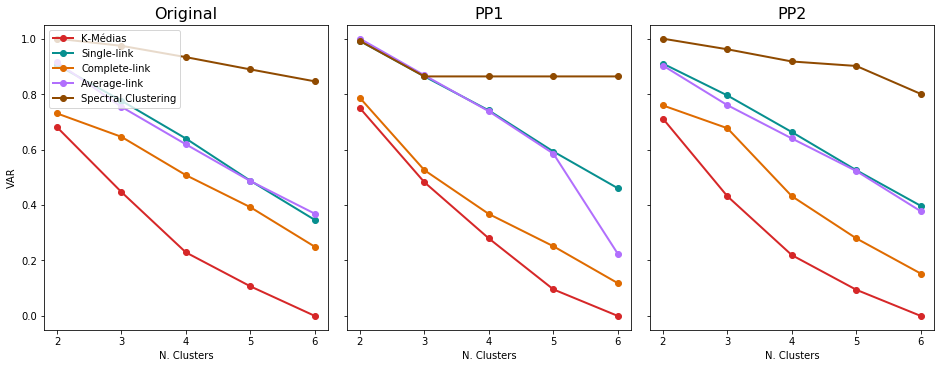

In [39]:
plot_internal_validation(partitions, datasets, algorithms, intracluster_variance, 'VAR', N_CLUSTERS, scale=True)

##### Conectividade (CON)

Assim como esperado, nas maioria das bases o *Single-link* teve excelentes resultados, alcançando valores mais baixos de conectividade quando comparado a outros algoritmos. Isso ocorre pelo mesmo ser um algoritmo de encadeamento, que favorece estruturas encadeadas.

Outro caso interessante é o comportamento do *Spectral Clustering*. O algoritmo obteve valores de conectividade extremamente elevados para as bases Original e PP2, mas foi o melhor algoritmo para a base PP1, superando até mesmo o *Single-link*.

O *Average-link* apresentou resultados bem próximos do *Single-link*. Por sua vez, o K-médias e o *Complete-link* se comportaram de maneira parecida, alcançando uma conectividade alta para todas as partições em todas as bases de dados.

Por fim, como era esperado, as melhores partições de cada algoritmo foram aquelas com 2 _clusters_. Como influenciam na conectividade apenas amostras vizinhas de _clusters_ diferentes, quanto menos _clusters_ temos, menos casos de _clusters_ conflitantes existirão para aumentar o índice.

**Nota sobre a implementação**: para facilitar a comparação, as CONs alcançadas pelos algoritmos em cada base foram normalizadas entre 0 e 1.

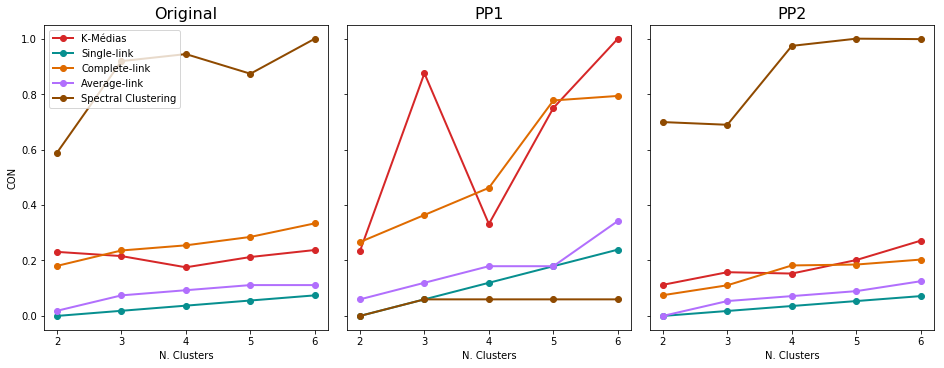

In [40]:
plot_internal_validation(partitions, datasets, algorithms, connectivity, 'CON', N_CLUSTERS, scale=True)

##### Silhueta (SIL)

Para a silhueta, obtivemos resultados bastante interessantes ao compararmos as três bases.

Inicialmente, para a base de dados original, temos uma clara superioridade do Single-link e do Average-link, alcançando valores maiores em todas as partições, enquanto o *Spectral Clustering* se saiu pior, sendo o único algoritmo a alcançar valores negativos. 

Entretanto, ao aplicarmos o índice sobre as partições da base PP1, temos uma melhora significativa do *Spectral Clustering* em relação às demais bases, sendo o melhor método para partições com 4 ou mais *clusters*. O *Single-link* e o *Average-link* também apresentaram resultados interessantes, sendo os melhores para partições com menos _clusters_ e os piores com partições de muitos *clusters*. O K-Médias e o *Complete-link* alcançaram resultados similares e medianos, se alternando entre partições para qual obteve a melhor silhueta.

Como a silhueta é um índice que leva mais de uma característica em consideração (compactação intracluster e distância entre *clusters*), não era esperado que um dos 5 algoritmos alcançasse índices superiores. Algoritmos que utilizam de critério de compactação, como o K-Médias, poderiam se sair melhor, mas caso os _clusters_ não estejam bem distanciados, não é possível afirmar a superioridade do mesmo (como visto nos gráficos). De forma geral, nenhuma combinação de algoritmo e base alcançou uma silhueta elevada (próxima de 1), não passando de 0,3 no melhor dos casos.

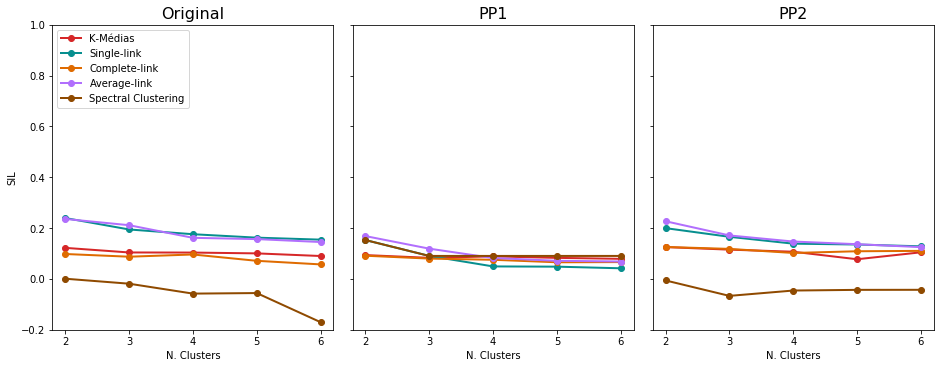

In [41]:
plot_internal_validation(partitions, datasets, algorithms, silhouette_score, 'SIL', N_CLUSTERS, yaxis_range=(-0.2, 1))

### B) Validação Externa

Tendo entendido como as estruturas das partições geradas se comportam, iremos para a validação externa. O objetivo principal dessa etapa é verificar como os agrupamentos criados se assemelham às classes reais do problema.

Dessa forma, iremos aplicar a validação externa comparando as partições geradas com duas partições diferentes. A primeira possui **2 *clusters*, de acordo com o tipo da leucemia**. Já a segunda, possui **3 *clusters*, de acordo com o subtipo da leucemia**.

A avaliação será feita através do **índice Rand Corrigido**, implementado em `sklearn.metrics.cluster.adjusted_rand_score`.

Para reaproveitar o código entre cada uma das comparações, implementaremos uma função de geração dos gráficos, `plot_external_validation`. A função recebe como entrada um `dict` com as partições geradas (`partitions`), as bases de dados e algoritmos utilizados para gerar as partições (`datasets` e `algorithms`), os rótulos reais (`labels_true`) e o número de _clusters_ (`n_clusters`).

In [42]:
def plot_external_validation(partitions, datasets, algorithms, labels_true, n_clusters, yaxis_range=None):
    best_scores = dict()
    fig, ax = plt.subplots(nrows=1, ncols=len(datasets), figsize=(13,5), constrained_layout=True, sharey=True)
    # Percorre as bases de dados
    for d, (dataset_name, _) in enumerate(datasets):
        best_scores[dataset_name] = dict()
        # Percorre os algoritmos
        colors = colorize(np.arange(len(algorithms)))
        for color, (algorithm_name, _) in zip(colors, algorithms):
            # Calcula o Indice Rand
            scores = [adjusted_rand_score(labels_true, partitions[dataset_name][algorithm_name][n]) for n in n_clusters]
            # Salva melhor resultado
            best_scores[dataset_name][algorithm_name] = max(scores)
            # Exibe o gráfico
            ax[d].plot(list(map(str, n_clusters)), scores, marker='o', label=algorithm_name, c=color, linewidth=2)
        ax[d].set_title(dataset_name, fontsize=16)        
        ax[d].set_xlabel('N. Clusters')        
        if yaxis_range is not None:
            ax[d].set_ylim(yaxis_range)
    ax[0].set_ylabel('ARI')
    ax[0].legend(loc='upper left')
    plt.plot()
    return best_scores

### Tipos de câncer - 2 _clusters_

Iremos inicialmente comparar as partições geradas com os dois tipos de leucemia existentes, **ALL** e **AML**.

Ao calcular o índice Rand (ARI) e gerar os gráficos, vemos uma clara superioridade do K-Médias, independente da base escolhida. Apenas na PP1, para 6 partições, que o *Average-link* foi superior. Em todos os outros cenários, o *Average-link* foi semelhante aos algoritmos restantes, não encontrando partições que correspondessem aos dados reais (ou seja, apresentando um índice Rand próximo de zero).

É muito interessante percebermos como o pré-processamento impactou profundamente os resultados: para a base Original, o K-Médias obteve um ARI extremamente baixo para a partição com 2 _clusters_ (curiosamente, o número de _clusters_ reais), tendo melhores resultados para 3 *clusters*. O mesmo método para a base PP1, alcançou o melhor ARI para a partição com 2 *clusters*, apresentando também bons resultados para as demais; Finalmente, para a base PP2, o comportamento do K-Médias foi semelhante com a base Original, mas é interessante perceber a melhora no método *Complete-link* a partir de 4 *clusters*.

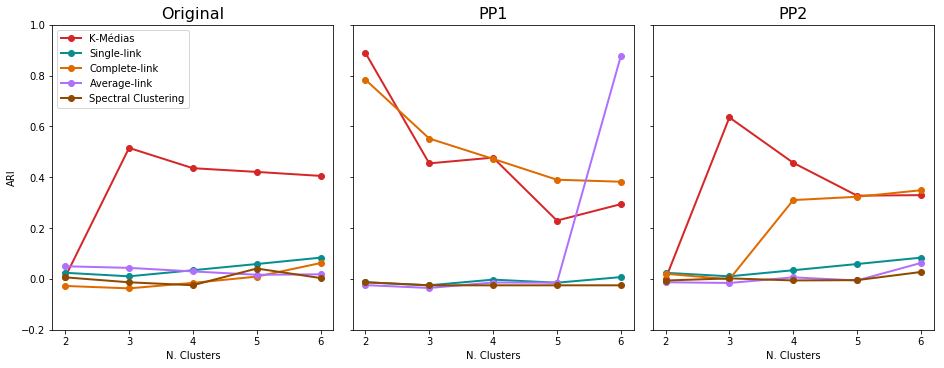

In [43]:
labels_true = df_metadata.loc[df_all.index]['ALL/AML']
best_scores = plot_external_validation(partitions, datasets, algorithms, labels_true, N_CLUSTERS, yaxis_range=[-0.2, 1])

##### Melhores resultados

Observando os melhores ARIs por base e partição, percebemos novamente como o pré-processamento é extremamente importante. Com exceção do *Single-link* e do *Spectral Clustering*, a base PP1 foi aque obteve os melhores ARIs. Não só isso, mas foi ela que obteve o melhor ARI geral: aproximadamente 0,89, para o K-Médias, um valor bastante positivo.

Vemos também que o K-médias foi o que alcançou os melhores valores independente da base. Os outros algoritmos apresentaram resultados bastante ruins para todas as bases, não passando de 0,1, com exceção do *Average-link* para a base PP1 e do *Complete-Link* para as bases PP1 e PP2, que alcançaram ARIs respectivos de 0,88, 0,78 e 0,35.

O resultado elevado do K-Médias para a base PP1 é bastante promissor, e mostra como é possível diferenciar os tipos de leucemia apenas com os microarranjos de DNA, sem ser necessário nem mesmo o rótulo, como no aprendizado supervisionado. Assim, é muito provável que seja possível identificar novos tipos de leucemia através de algoritmos de agrupamento.

In [44]:
display(pd.DataFrame(best_scores).transpose())

,Average-link,Complete-link,K-Médias,Single-link,Spectral Clustering
Original,0.049974,0.062614,0.515566,0.083808,0.041122
PP1,0.876025,0.784352,0.889738,0.007321,-0.012939
PP2,0.063048,0.349073,0.635430,0.083808,0.027420


### Subtipos de câncer - 3 _clusters_

Agora, iremos comparar as partições com os dois subtipos de ALL, **T-Cell** e **B-Cell**, e o tipo **AML**, criando assim uma partição conhecida de 3 *clusters*.

Aplicando o ARI sobre as partições geradas pelos algoritmos, temos, novamente, uma superioridade do K-Médias, com gráficos levemente semelhantes com os anteriores, incluindo a melhora do Average-link com 6 *clusters* para a base PP1.

Da mesma forma, podemos perceber a influência que o pré-processamento causa nos resultados finais, alterando o número de _clusters_ da melhor partição por base.

Um ponto curioso dos valores obtidos é o fato de que nenhum dos melhores resultados por base se deu na partição com 3 *clusters*. Para a base Original, a melhor partição encontrada possui 5 *clusters*. Já para as bases PP1 e PP2, as melhores partições foram as de 4 *clusters*.

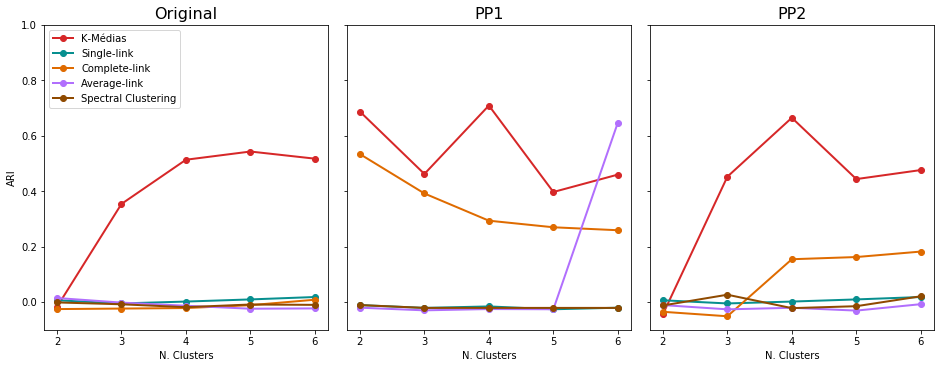

In [45]:
class_encoder = {subtype:'AML' for subtype in df_metadata[df_metadata['ALL/AML']=='AML']['Subtype'].unique()}
labels_true = df_metadata.loc[df_all.index]['Subtype'].replace(class_encoder)
best_scores = plot_external_validation(partitions, datasets, algorithms, labels_true, N_CLUSTERS, yaxis_range=[-0.1, 1])

Observando os melhores valores de cada algoritmo para cada base de dados, comprovamos a superioridade do K-Médias, que se saiu melhor para todas as bases. 

Assim como no cenário anterior, a base PP1 foi a que obteve o melhor resultado.

O melhor ARI alcançado foi aproximadamente 0,71. Por ser um valor menor que o apresentado na outra comparação (0,89), podemos dizer que os algoritmos têm maior dificuldade em dividir as amostras pelo subtipo do que pelo tipo. Ainda assim, o valor alcançado é razoável, mostrando que talvez seja possível encontrar novos subtipos de leucemia através do aprendizado não supervisionado.

In [46]:
display(pd.DataFrame(best_scores).transpose())

,Average-link,Complete-link,K-Médias,Single-link,Spectral Clustering
Original,0.014635,0.008500,0.542940,0.018232,-0.001269
PP1,0.647345,0.533687,0.708858,-0.010825,-0.010825
PP2,-0.007575,0.182130,0.664669,0.018232,0.026524


## Conclusão

Neste *notebook*, reproduzimos parcialmente o experimento conduzido por Golub *et al.* em [3]. Nele, utilizamos uma base real de microarranjos de DNA de pacientes com Leucemia, para verificar na prática como são as etapas de análise exploratória e pré-processamento, e resolver problemas de classificação e agrupamento.

Com o término do experimento, podemos concluir dois pontos principais: *(i)* é possível descobrir qual o tipo e subtipo de leucemia através de algoritmos inteligentes, fornecendo apenas a expressão gênica do paciente; e *(ii)* a etapa de pré-processamento e escolha de algoritmo pode impactar bastante nos resultados finais, como observado nos gráficos e tabelas geradas.

Com o *notebook*, espera-se que o leitor tenha compreendido como pode ser realizado um experimento completo da área de aprendizado de máquina, utilizando para isso um cenário real. Sendo assim, é esperado que o leitor possa aplicar seus conhecimentos para outros problemas, contribuindo assim para suas soluções.

---
---
## Explore o *notebook*!

Agora é sua vez! Retorne ao começo deste _notebook_ e faça mudanças nos códigos para agregar ainda mais ao experimento!

A seguir, algumas ideias de mudanças são sugeridas...

### Verifique o resultado sobre outros metadados

Verifique os resultados obtidos na classificação e no agrupamento para os outros metadados das amostras, como **BM/PB**, **Gender**, **Treatment Response** e **Source**. Será que mais algum dado pode ser descoberto através do microarranjo de DNA?

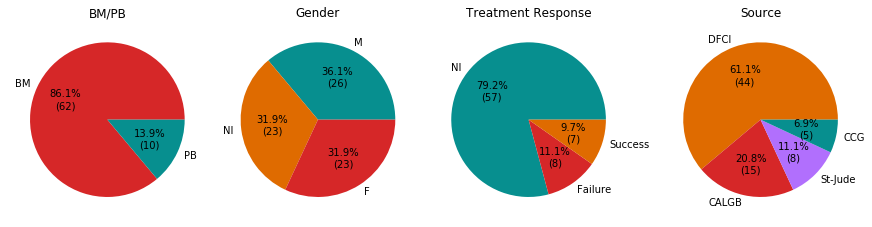

In [47]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(12, 5), constrained_layout=True)
for i, column in enumerate(['BM/PB', 'Gender', 'Treatment Response', 'Source']):
    counts = df_metadata[column].value_counts()
    ax[i].pie(counts.values, labels=counts.index, autopct=lambda x: pie_format(x, counts.values), colors=colorize(counts.index))
    ax[i].set_title(column)
plt.show()

### Aplique outras etapas no pré-processamento

Gere outras bases na etapa de pré-processamento, mude o que foi feito para gerar as bases PP1 e PP2. Verifique se você consegue melhorar os resultados obtidos apenas com essas mudanças!

### Teste outros algoritmos de classificação e agrupamento

A biblioteca `scikit-learn` possui diversos algoritmos de classificação aplicáveis para os problemas deste experimento. Verifique se outros algoritmso melhoram os resultados obtidos!

In [48]:
# Algoritmos de classificação
from sklearn.ensemble import AdaBoostClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Algoritmos de agrupamento
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AffinityPropagation
from sklearn.cluster import Birch
from sklearn.cluster import DBSCAN
from sklearn.cluster import MeanShift
from sklearn.cluster import OPTICS

---
---
## Referências

[1] Colombo, J. and Rahal, P. "A tecnologia de microarray no estudo do câncer de cabeça e pescoço," in *Revista Brasileira de Biociências*, vol. 8, no. 1, 2010, pp. 64-72. URL: http://www.ufrgs.br/seerbio/ojs/index.php/rbb/article/view/1268 

[2] Dudoit, S., Fridlyand, J. and Speed, T. P. "Comparison of Discrimination Methods for the Classification of Tumors Using Gene Expression Data," in *Journal of the American Statistical Association*, vol. 97, no. 457, 2002, pp. 77-87. DOI: 10.1198/016214502753479248. URL: https://amstat.tandfonline.com/doi/abs/10.1198/016214502753479248#.XqGT4X7QgfN

[3] Golub, T. R., Slonim, D. K., Tamayo, P., Huard, C., Gaasenbeek, M., Mesirov, J. P., Coller, H., Loh, M. L., Downing, J. R., Caligiuri, M. A., Bloomfield, C. D., Lander, E. S. "Molecular Classification of Cancer: Class Discovery and Class Prediction by Gene Expression Monitoring," in *SCIENCE*, vol.286, 1999, pp. 531-537. DOI: 10.1126/science.286.5439.531. URL: https://www.ncbi.nlm.nih.gov/pubmed/10521349

[4] Khan, J., Simon, R., Bittner, M., Chen, Y., Leighton, S. B., Pohida, T., Smith, P. D., Jiang, Y., Gooden, G. C., Trent, J. M. and Meltzer, P. S. "Gene expression profiling of alveolar rhabdomyosarcoma with cDNA microarrays," in *Cancer Res*, vol. 58, no. 22, 1998, pp. 5009-5013. URL: https://www.ncbi.nlm.nih.gov/pubmed/9823299

[5] Niemeyer, C. M. and Blohm, D. "DNA Microarrays," in *Angewandte Chemie International Edition*, vol. 38, no. 19, 1999, pp. 2865-2869. DOI: 10.1002/(sici)1521-3773(19991004)38:19<2865::aid-anie2865>3.0.co;2-f. URL: https://onlinelibrary.wiley.com/doi/epdf/10.1002/(SICI)1521-3773(19991004)38:19<2865::AID-ANIE2865>3.0.CO;2-F

[6] Southern, E. M. "Detection of specific sequences among DNA fragments separated by gel electrophoresis," in *Journal of Molecular Biology*, vol. 98, no. 3, 1975, pp.503-517. DOI: 10.1016/s0022-2836(75)80083-0. URL: http://europepmc.org/article/MED/1195397